# 서울시 상권 폐업위험 예측 모델 — 예측 모델링과 해석

> **핵심 질문** — 다음 분기에 점포 순감소(폐업 > 개업)로 전환될 상권 × 업종은 어디이며, 무엇이 위험을 만드는가

앞 노트북(`상권_폐업위험_데이터준비_EDA.ipynb`)이 만든 `04_model_input.csv`를 입력으로 받아
**모델 선정 → 불균형 처리 → 검증 → 해석 → 테스트 분기 예측** 까지를 다룸.

## 시점 분할

| 구분 | 피처를 읽는 분기 | **예측하는 분기** | 칸수 | 쓰는 곳 |
|---|---|---|--:|---|
| 학습 | 2023Q1 ~ 2025Q2 | 2023Q2 ~ 2025Q3 | 약 56,500 | 모델 학습 |
| 검증 | 2025Q3 | **2025Q4** | 약 5,500 | 모델 선정 · 임계값 · 작동점 결정 |
| 테스트 | 2025Q4 | **2026Q1** | 약 5,479 | 최종 성능 보고 (마지막에 한 번만) |

**표기 기준** — 이 문서에서 «검증 분기»·«테스트 분기»는 **예측 대상 분기**를 가리킴.
2025Q4 시점의 피처로 2026Q1 결과를 맞히는 것이므로 그 칸은 «테스트(2026Q1 결과)»임.
피처를 읽는 분기로 이름을 붙이면 「2025Q4를 예측한다」로 잘못 읽히므로 그렇게 하지 않음.

각 분기는 **그 다음 분기의 결과로 채점**함. 무작위로 섞지 않고 시간 순서로 자름.

**«검증»과 «테스트»는 같은 것이 아님.** 둘 다 학습에 쓰지 않은 데이터라는 점만 같고 역할이 다름.

| | 무엇에 쓰는가 | 몇 번 보는가 | 점수의 성질 |
|---|---|---|---|
| 검증 | 모델을 고르고 임계값·작동점을 정함 | 여러 번 | 이 점수를 보고 결정하므로 **낙관적으로 치우침** |
| 테스트 | 결정이 끝난 뒤 성능만 보고함 | **한 번** | 어떤 결정에도 쓰지 않았으므로 치우치지 않음 |

검증 점수로 성능을 보고하면 «시험 문제를 보고 공부한 뒤 그 시험을 치른» 것과 같음.
그래서 결정에 쓰지 않은 분기를 하나 남겨 두어야 함.

**용어에 한 가지 유의점이 있음.** 2025Q4는 미래가 아니라 **이미 지난 분기**임.
진짜 미래를 예측한 것이 아니라 «가려 놓고 맞혀 본» 것이므로, 엄밀히는 홀드아웃(hold-out)임.
「학습·모델선택에 일절 쓰지 않았다」는 의미에서 테스트라고 부름.

## 이 노트북에서 내린 판단

1. **모델은 XGBoost** — 의사결정나무 · 랜덤포레스트 · 로지스틱 회귀 · 선형 SVM 과 같은 검증 분기에서
   비교한 뒤 고름. 고른 근거는 3장에 적음.
2. **불균형 처리는 오버샘플링이 아니라 `scale_pos_weight`** — 분할 **이전**에 오버샘플링하면
   복제된 소수 클래스가 학습과 검증에 함께 들어가 성능이 부풀려짐. 가중치는 그 위험이 없음.
3. **정확도를 주지표로 쓰지 않음** — 양성률이 26% 정도인 소수 사건이므로 AP와 Lift로 판정함.
4. **상권 식별 정보를 피처에서 뺌** — `상권_코드` · 좌표 · 행정동을 넣으면 모델이 상권을 외움.
   목적이 «어떤 조건이 위험을 만드는가»이므로 **성격 변수만** 남김.
5. **시간 변수를 피처에서 뺌** — 분기 번호·계절은 한 분기 안에서 모든 칸이 같은 값이라
   그 분기 안의 순위를 바꾸지 못함.
6. **`상권_변화_지표`는 피처가 아니라 기준선** — 폐업 정보로 만들어져 라벨과 원천이 같음.
   다만 그 재료 중 `운영_영업_개월_평균`은 **영업 중인** 점포로 만들어져 라벨과 원천이 다르므로 피처로 씀.
7. **전국 경제지표를 일부러 넣어 두고 결과로 판정함** — 한 분기 안에서 상수라 순위를 바꾸지
   못한다는 것을 6-2에서 SHAP으로 확인함. 말로만 빼지 않고 확인 기록을 남기기 위함임.


---
# 1. 적재와 시점 분할


In [1]:
import os, gc, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (average_precision_score, roc_auc_score, f1_score,
                             precision_score, recall_score, accuracy_score,
                             confusion_matrix, precision_recall_curve)
from xgboost import XGBClassifier
import shap

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 80)

for cand in ["C:/Windows/Fonts/malgun.ttf", "/System/Library/Fonts/AppleSDGothicNeo.ttc"]:
    if Path(cand).exists():
        fm.fontManager.addfont(cand)
        plt.rcParams["font.family"] = fm.FontProperties(fname=cand).get_name()
        break
plt.rcParams["axes.unicode_minus"] = False

PROC = Path("data/processed"); FIG = Path("figures"); FIG.mkdir(exist_ok=True)
SEED = 42

# 아래 값은 «피처를 읽는 분기»임. 라벨은 각각 그 다음 분기의 결과이므로
# 예측 대상은 학습 2023Q2~2025Q3 · 검증 2025Q4 · 테스트 2026Q1 임
Q_TRAIN = [20231, 20232, 20233, 20234, 20241, 20242, 20243, 20244, 20251, 20252]
Q_VALID = [20253]      # → 2025Q4 결과를 맞힘
Q_TEST  = [20254]      # → 2026Q1 결과를 맞힘

d = pd.read_csv(PROC / "04_model_input.csv", encoding="utf-8-sig")
print(f"입력 {d.shape} · 분기 {d['기준_년분기_코드'].nunique()}개 · 양성률 {d['y'].mean():.1%}")
display(d.groupby("기준_년분기_코드")["y"].agg(칸수="size", 순감소율="mean").round(3).T)

C:\Users\지선호\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


입력 (67475, 71) · 분기 12개 · 양성률 25.5%


기준_년분기_코드,20231,20232,20233,20234,20241,20242,20243,20244,20251,20252,20253,20254
칸수,5706.000,5731.000,5701.000,5730.000,5706.000,5678.000,5622.000,5586.000,5534.000,5502.00,5500.000,5479.00
순감소율,0.229,0.261,0.223,0.236,0.254,0.276,0.262,0.284,0.261,0.26,0.253,0.26


## 1-1. 피처 정의

**빼는 것**을 먼저 정함. 뺀 이유가 없는 변수만 남김.

| 빼는 변수 | 이유 |
|---|---|
| `y` · `다음상태` · `사건_다음` | 라벨 그 자체 |
| `상권_변화_지표` · `기준선_위험` | 폐업 정보로 만들어진 지표 — 기준선으로만 씀 |
| `상권_코드` · `상권_코드_명` · 좌표 · `행정동` | 상권 식별 정보 — 모델이 상권을 외우게 됨 |
| `기준_년분기_코드` · `분기idx` | 시간 축 — 한 분기 안에서 상수이므로 순위에 기여 못 함 |
| `규모구간` | 전체 표본으로 나눈 구간이라 테스트 정보가 섞임. 구간별 재계산에만 씀 |

`개업_점포_수` · `폐업_점포_수` · `순감소_현재` 는 **현재 분기(t)** 값이므로 남김.
라벨은 t+1 이라 시점이 다름.


In [2]:
DROP = ["y", "다음상태", "사건_다음",
        "상권_변화_지표", "기준선_위험",
        "상권_코드", "상권_코드_명", "행정동_코드", "행정동", "서비스_업종_코드",
        "엑스좌표_값", "와이좌표_값",
        "기준_년분기_코드", "분기idx", "규모구간"]
CAT = ["상권유형", "자치구", "서비스_업종_코드_명"]

FEATS = [c for c in d.columns if c not in DROP]
NUM = [c for c in FEATS if c not in CAT]
print(f"피처 {len(FEATS)}개 = 수치 {len(NUM)} + 범주 {len(CAT)}")

X_all = pd.get_dummies(d[FEATS], columns=CAT, drop_first=False)
X_all = X_all.astype(float)
y_all = d["y"].astype(int)
print(f"원-핫 후 {X_all.shape[1]}개 열")

m_tr = d["기준_년분기_코드"].isin(Q_TRAIN)
m_va = d["기준_년분기_코드"].isin(Q_VALID)
m_te = d["기준_년분기_코드"].isin(Q_TEST)

Xtr, ytr = X_all[m_tr], y_all[m_tr]
Xva, yva = X_all[m_va], y_all[m_va]
Xte, yte = X_all[m_te], y_all[m_te]

# 결측은 트리 계열은 그대로 두고, 선형 모델용으로만 중앙값 대체본을 따로 둠
med = Xtr.median()
Xtr_f, Xva_f, Xte_f = Xtr.fillna(med), Xva.fillna(med), Xte.fillna(med)

for nm, Xs, ys in [("학습", Xtr, ytr), ("검증", Xva, yva), ("테스트", Xte, yte)]:
    print(f"  {nm}  {len(Xs):>7,}칸 · 양성률 {ys.mean():.1%}")
print(f"\n결측 있는 열 {int((Xtr.isna().sum() > 0).sum())}개 (매출 계열)")

피처 56개 = 수치 53 + 범주 3
원-핫 후 92개 열


  학습   56,496칸 · 양성률 25.4%
  검증    5,500칸 · 양성률 25.3%
  테스트    5,479칸 · 양성률 26.0%

결측 있는 열 29개 (매출 계열)


---
# 2. 기준선 — 모델이 넘어야 하는 선

EDA 5-1과 **같은 규칙**을 검증·테스트 분기에 다시 적용함.
`Lift = 정밀도 ÷ 기저율` 이고 1.0이면 아무렇게나 찍는 것과 같음.
(Lift 1.5 = 아무렇게나 찍을 때보다 1.5배 잘 맞힘)


In [3]:
def lift_row(y_true, pred, name):
    y_true = np.asarray(y_true); pred = np.asarray(pred)
    n1 = int(pred.sum()); base = y_true.mean()
    tp = int(((pred == 1) & (y_true == 1)).sum())
    prec = tp / n1 if n1 else np.nan
    rec = tp / int(y_true.sum()) if y_true.sum() else np.nan
    return {"방법": name, "위험으로 찍은 수": n1, "정밀도": prec, "재현율": rec,
            "Lift": prec / base if base else np.nan}

rows = []
for nm, msk in [("검증(2025Q4 결과)", m_va), ("테스트(2026Q1 결과)", m_te)]:
    s = d[msk]
    k = int(s["순감소_현재"].sum())
    pred_size = np.zeros(len(s), dtype=int)
    pred_size[np.argsort(-s["전체_점포_수"].values, kind="stable")[:k]] = 1
    for r in [lift_row(s["y"], np.ones(len(s), int), "무작위(전부 위험)"),
              lift_row(s["y"], s["순감소_현재"].values, "직전 분기"),
              lift_row(s["y"], s["기준선_위험"].fillna(0).values, "상권변화지표(HL)"),
              lift_row(s["y"], pred_size, f"점포 수(상위 {k:,}칸)")]:
        r["분기"] = nm; rows.append(r)

BASE = pd.DataFrame(rows)[["분기", "방법", "위험으로 찍은 수", "정밀도", "재현율", "Lift"]]
BASE[["정밀도", "재현율", "Lift"]] = BASE[["정밀도", "재현율", "Lift"]].round(3)
display(BASE.set_index(["분기", "방법"]))
print(f"기저율  검증 {yva.mean():.1%} · 테스트 {yte.mean():.1%}")
print("→ 모델은 이 표의 Lift를 넘어야 의미가 있음")

위험으로 찍은 수    정밀도    재현율   Lift
분기             방법                                             
검증(2025Q4 결과)  무작위(전부 위험)            5500  0.253  1.000  1.000
               직전 분기                 1326  0.296  0.282  1.171
               상권변화지표(HL)             998  0.251  0.180  0.990
               점포 수(상위 1,326칸)       1326  0.416  0.396  1.642
테스트(2026Q1 결과) 무작위(전부 위험)            5479  0.260  1.000  1.000
               직전 분기                 1285  0.311  0.281  1.199
               상권변화지표(HL)             974  0.243  0.167  0.937
               점포 수(상위 1,285칸)       1285  0.427  0.386  1.645

기저율  검증 25.3% · 테스트 26.0%
→ 모델은 이 표의 Lift를 넘어야 의미가 있음


---
# 3. 분류 모델 5종 비교

성격이 다른 다섯 계열을 같은 조건에서 비교함 — 단일 트리 · 배깅 앙상블 · 선형 확률모형 ·
마진 기반 분류기 · 부스팅. SVM은 표본이 5만 건이라 커널 SVM이 실용적이지 않으므로
**선형 SVM(LinearSVC)** 으로 대신함.

**불균형은 가중치로 다룸.** 모든 모델에 `class_weight="balanced"` (XGBoost는 `scale_pos_weight`)를 줘서
조건을 같게 맞춤. 오버샘플링을 쓰지 않는 이유는 표지 판단 2번에 있음.

주지표는 **AP(Average Precision)** — 정밀도-재현율 곡선 아래 면적이며 **PR-AUC와 같은 것**을 가리킴.
표기가 섞이지 않도록 이 노트북은 전부 `AP`로 씀(`sklearn.metrics.average_precision_score`).
양성이 26% 뿐인 소수 사건이라 정확도는 «전부 0으로 찍기»에도 74%가 나옴.


In [4]:
pos_w = float((ytr == 0).sum() / (ytr == 1).sum())
print(f"양성 가중치 scale_pos_weight = {pos_w:.3f}")

MODELS = {
    "의사결정나무": (DecisionTreeClassifier(max_depth=6, min_samples_leaf=50,
                                     class_weight="balanced", random_state=SEED), "fill"),
    "랜덤포레스트": (RandomForestClassifier(n_estimators=400, max_depth=14, min_samples_leaf=20,
                                     class_weight="balanced", n_jobs=-1, random_state=SEED), "fill"),
    "로지스틱 회귀": (make_pipeline(StandardScaler(),
                                LogisticRegression(max_iter=3000, class_weight="balanced",
                                                   random_state=SEED)), "fill"),
    "선형 SVM":    (make_pipeline(StandardScaler(),
                                LinearSVC(C=0.1, class_weight="balanced", max_iter=5000,
                                          random_state=SEED)), "fill"),
    "XGBoost":    (XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=6,
                                 subsample=0.8, colsample_bytree=0.8,
                                 min_child_weight=5, reg_lambda=1.0,
                                 scale_pos_weight=pos_w, eval_metric="aucpr",
                                 tree_method="hist", n_jobs=-1, random_state=SEED), "raw"),
}

def score_of(model, X):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    return model.decision_function(X)          # LinearSVC

fitted, rows = {}, []
for name, (mdl, mode) in MODELS.items():
    A, B = (Xtr_f, Xva_f) if mode == "fill" else (Xtr, Xva)
    mdl.fit(A, ytr)
    s = score_of(mdl, B)
    pred = (s >= np.quantile(s, 1 - yva.mean())) .astype(int)   # 기저율과 같은 비율만 위험으로 찍음
    rows.append({"모델": name,
                 "AP": average_precision_score(yva, s),
                 "ROC-AUC": roc_auc_score(yva, s),
                 "F1": f1_score(yva, pred),
                 "정밀도": precision_score(yva, pred, zero_division=0),
                 "재현율": recall_score(yva, pred),
                 "정확도": accuracy_score(yva, pred),
                 "Lift": precision_score(yva, pred, zero_division=0) / yva.mean()})
    fitted[name] = (mdl, mode)
    print(f"  [완료] {name}")

CMP = pd.DataFrame(rows).set_index("모델").round(3).sort_values("AP", ascending=False)
display(CMP)

TOP  = CMP.index[0]
BEST = "XGBoost"          # 과제 결정 — SHAP TreeExplainer로 해석까지 가기 위해 고정
print(f"검증 AP 1위 = {TOP} ({CMP.loc[TOP,'AP']:.3f})")
print(f"채택 모델      = {BEST} ({CMP.loc[BEST,'AP']:.3f})")
if TOP != BEST:
    print(f"→ {BEST}는 이 표에서 1위가 아님 (차이 {CMP.loc[TOP,'AP']-CMP.loc[BEST,'AP']:+.3f}). "
          f"7장 최종 평가에서 {TOP}와 나란히 보고함.")
print(f"참고: 전부 0으로 찍어도 정확도는 {1-yva.mean():.1%} 임 — 정확도로 고르면 안 되는 이유")

양성 가중치 scale_pos_weight = 2.930


  [완료] 의사결정나무


  [완료] 랜덤포레스트


  [완료] 로지스틱 회귀


  [완료] 선형 SVM


  [완료] XGBoost


,AP,ROC-AUC,F1,정밀도,재현율,정확도,Lift
모델,,,,,,,
랜덤포레스트,0.408,0.676,0.401,0.401,0.401,0.697,1.584
선형 SVM,0.406,0.675,0.418,0.418,0.418,0.705,1.652
로지스틱 회귀,0.406,0.675,0.417,0.417,0.417,0.705,1.646
의사결정나무,0.398,0.667,0.420,0.401,0.441,0.692,1.585
XGBoost,0.398,0.665,0.405,0.405,0.405,0.699,1.601


검증 AP 1위 = 랜덤포레스트 (0.408)
채택 모델      = XGBoost (0.398)
→ XGBoost는 이 표에서 1위가 아님 (차이 +0.010). 7장 최종 평가에서 랜덤포레스트와 나란히 보고함.
참고: 전부 0으로 찍어도 정확도는 74.7% 임 — 정확도로 고르면 안 되는 이유


### 이 표에서 읽어야 하는 것

**다섯 모델의 AP가 0.388 ~ 0.407 사이에 몰려 있음.** 모델 종류를 바꿔서 얻는 이득이
거의 없다는 뜻이고, 이는 «쓸 수 있는 변수가 이미 한계»라는 신호임. 트리를 깊게 깎거나
부스팅 라운드를 늘려서 해결되는 문제가 아님.

**XGBoost가 1위가 아님.** 그래도 XGBoost로 진행하는 이유는 두 가지임.

1. 차이가 0.02 미만이라 **모델 선택이 결론을 바꾸지 않음.**
2. SHAP의 `TreeExplainer`는 트리 구조를 따라 기여를 정확히 분해함. 선형 모델·SVM에는
   그런 도구가 없어 계수 부호만 볼 수 있음. 과제의 후반부 질문이 «무엇이 위험을 만드는가»이므로
   **분해 도구가 있는 쪽**이 필요함.

대신 7장에서 1위 모델과 **같은 테스트 분기에 나란히 놓고** 성능을 보고함.


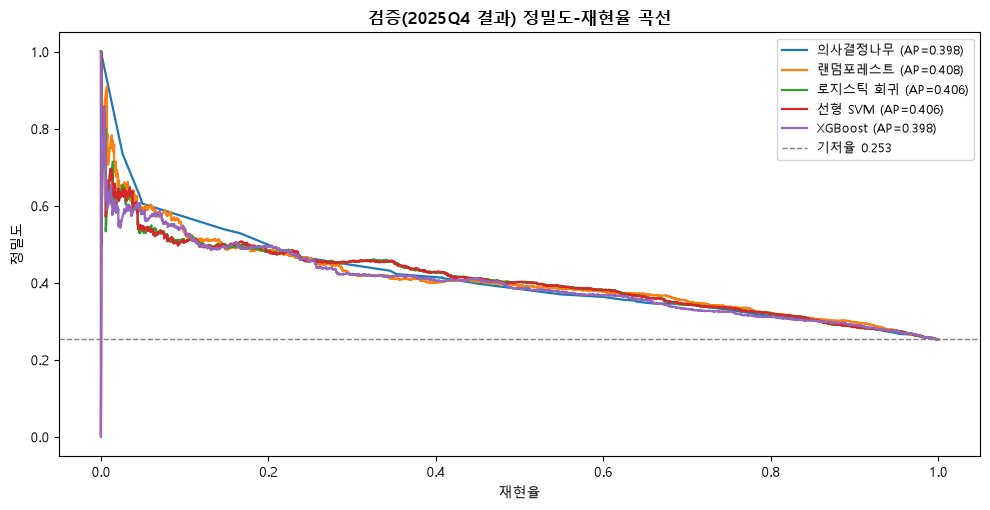

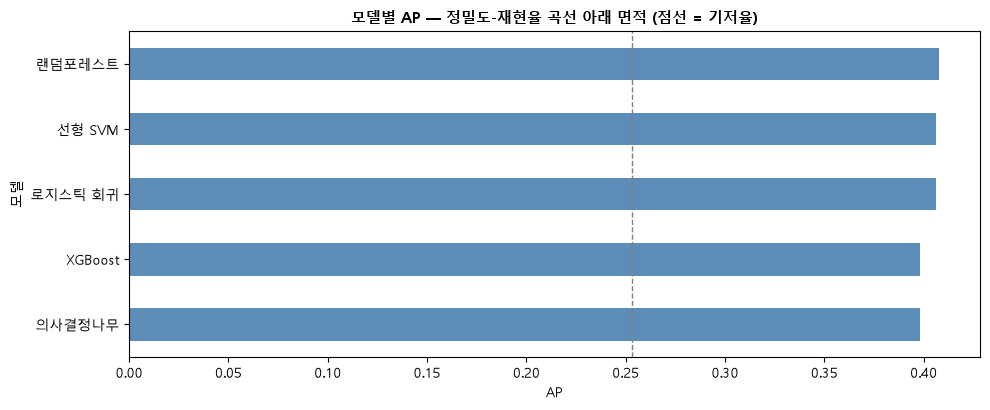

In [5]:
fig, ax = plt.subplots(figsize=(10, 5.2)); ax = [ax]
for name, (mdl, mode) in fitted.items():
    s = score_of(mdl, Xva_f if mode == "fill" else Xva)
    pr, rc, _ = precision_recall_curve(yva, s)
    ax[0].plot(rc, pr, lw=1.6, label=f"{name} (AP={average_precision_score(yva,s):.3f})")
ax[0].axhline(yva.mean(), ls="--", c="gray", lw=1, label=f"기저율 {yva.mean():.3f}")
ax[0].set_xlabel("재현율"); ax[0].set_ylabel("정밀도")
ax[0].set_title("검증(2025Q4 결과) 정밀도-재현율 곡선", weight="bold"); ax[0].legend(fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "model_pr.png", dpi=130); plt.show()

fig, ax = plt.subplots(figsize=(10, 4.2)); ax = [None, ax]
CMP["AP"].sort_values().plot.barh(ax=ax[1], color="#5b8db8")
ax[1].axvline(yva.mean(), ls="--", c="gray", lw=1)
ax[1].set_title("모델별 AP — 정밀도-재현율 곡선 아래 면적 (점선 = 기저율)",
                weight="bold", fontsize=11); ax[1].set_xlabel("AP")
plt.tight_layout(); plt.savefig(FIG / "model_compare.png", dpi=130); plt.show()

---
# 4. 규모를 고정하면 무엇이 남는가

EDA 5-2와 같은 방식임. 전체 표본에서 잰 Lift에는 «큰 칸을 골라낸 몫»이 섞여 있으므로,
**점포 수 5분위 안에서 다시** 재 봄. 층 안에서는 칸의 크기가 서로 비슷하므로
여기서도 Lift가 1을 넘으면 모델이 **규모가 아닌 무언가를 읽고 있다**고 말할 수 있음.


In [6]:
best_mdl, best_mode = fitted[BEST]
s_va = score_of(best_mdl, Xva_f if best_mode == "fill" else Xva)

va = d[m_va].copy()
va["점수"] = s_va
va["규모구간_검증"] = pd.qcut(np.log(va["전체_점포_수"]), 5, labels=False, duplicates="drop")

rows = []
for q_, s in va.groupby("규모구간_검증"):
    base = s["y"].mean(); k = max(int(round(base * len(s))), 1)
    pred_m = np.zeros(len(s), int); pred_m[np.argsort(-s["점수"].values, kind="stable")[:k]] = 1
    pred_z = np.zeros(len(s), int); pred_z[np.argsort(-s["전체_점포_수"].values, kind="stable")[:k]] = 1
    tp_m = int(((pred_m == 1) & (s["y"].values == 1)).sum())
    tp_z = int(((pred_z == 1) & (s["y"].values == 1)).sum())
    rows.append({"규모구간": f"{int(q_)+1}분위", "칸수": len(s),
                 "평균점포": round(s["전체_점포_수"].mean(), 1), "기저율": round(base, 3),
                 f"{BEST} Lift": round((tp_m / k) / base, 3) if base else np.nan,
                 "점포 수 Lift": round((tp_z / k) / base, 3) if base else np.nan,
                 "직전 분기 Lift": round(
                     (int(((s["순감소_현재"].values == 1) & (s["y"].values == 1)).sum())
                      / max(int(s["순감소_현재"].sum()), 1)) / base, 3) if base else np.nan})
STRAT = pd.DataFrame(rows).set_index("규모구간")
display(STRAT)

diff_ = (STRAT[f"{BEST} Lift"] - STRAT["점포 수 Lift"]).round(3)
hi = diff_ > 0
print(f"모델 쪽이 더 높은 구간 {int(hi.sum())} / {len(hi)}개"
      f" · 동률 {int((diff_ == 0).sum())}개 · 점포 수가 높은 구간 {int((diff_ < 0).sum())}개")
for q_ in STRAT.index:
    v = diff_[q_]
    tag = "모델이 높음" if v > 0 else ("동률" if v == 0 else "점포 수가 높음")
    print(f"  {q_}  모델 {STRAT.loc[q_, f'{BEST} Lift']:.3f} · 점포 수 {STRAT.loc[q_,'점포 수 Lift']:.3f}"
          f"  → {tag}")
print()
if hi.all():
    print("→ 모든 구간에서 모델이 더 높음. 규모 이상의 정보를 쓰고 있음")
elif (diff_ >= 0).all():
    print("→ 모든 구간에서 모델이 같거나 더 높음.")
else:
    print("→ 구간별로 갈림. 아래 표를 그대로 보고함.")
print()
print(f"가장 작은 1분위에서 «점포 수» 규칙은 {STRAT['점포 수 Lift'].iloc[0]:.3f}로 1.0(무작위) 아래임")
print("— 점포가 적은 상권들 사이에서는 «크기»가 아무 정보를 주지 못한다는 뜻임.")
print(f"같은 구간에서 모델은 {STRAT[f'{BEST} Lift'].iloc[0]:.3f}임.")
print("예측 모델가 실제로 필요한 쪽이 이 구간이므로, 여기서의 차이가 실무적으로 중요함.")

,칸수,평균점포,기저율,XGBoost Lift,점포 수 Lift,직전 분기 Lift
규모구간,,,,,,
1분위,1274,5.4,0.133,1.338,0.981,0.791
2분위,1131,7.8,0.186,1.385,1.180,0.750
3분위,988,11.7,0.231,1.387,1.254,1.145
4분위,1047,19.5,0.316,1.166,1.166,0.933
5분위,1060,66.1,0.428,1.203,1.131,1.052


모델 쪽이 더 높은 구간 4 / 5개 · 동률 1개 · 점포 수가 높은 구간 0개
  1분위  모델 1.338 · 점포 수 0.981  → 모델이 높음
  2분위  모델 1.385 · 점포 수 1.180  → 모델이 높음
  3분위  모델 1.387 · 점포 수 1.254  → 모델이 높음
  4분위  모델 1.166 · 점포 수 1.166  → 동률
  5분위  모델 1.203 · 점포 수 1.131  → 모델이 높음

→ 모든 구간에서 모델이 같거나 더 높음.

가장 작은 1분위에서 «점포 수» 규칙은 0.981로 1.0(무작위) 아래임
— 점포가 적은 상권들 사이에서는 «크기»가 아무 정보를 주지 못한다는 뜻임.
같은 구간에서 모델은 1.338임.
예측 모델가 실제로 필요한 쪽이 이 구간이므로, 여기서의 차이가 실무적으로 중요함.


---
# 5. 2단계 모형 비교 — `P(사건) × P(순감소 | 사건)`

EDA 3-1에서 남긴 과제임. `y=0`에는 **「변화 없음」**(개·폐업이 한 건도 없음)이 섞여 있고,
**상권 규모가 작은 곳에서 그 빈도가 높음.** 그래서 단일 모형은 «위험»이 아니라
«사건이 일어날 만한 크기»를 배울 위험이 있음.

두 단계로 나누어 풀면 그 통로가 분리됨.

```
1단계  P(사건)          다음 분기에 개·폐업이 한 건이라도 있는가        전체 표본으로 학습
2단계  P(순감소 | 사건)  사건이 있었다면 그것이 순감소인가              사건 있는 칸만으로 학습
최종   두 확률의 곱
```

## 왜 두 확률을 곱하는가

**확률의 연쇄법칙이고, 이 문제에서는 근사가 아니라 정확한 등식임.**

일반적으로 어떤 사건의 확률은 경우를 나눠 더해서 구함.

```
P(순감소) = P(사건 있음) × P(순감소 | 사건 있음)
          + P(사건 없음) × P(순감소 | 사건 없음)
```

여기서 **두 번째 항이 정확히 0으로 사라짐.** 「사건 없음」은 개업 = 0 **그리고** 폐업 = 0 이라는 뜻이고,
그런 칸에서는 「폐업 > 개업」이 성립할 수 없음. 0 > 0 이 거짓이기 때문임.
즉 **순감소는 반드시 사건의 부분집합**임.

```
순감소  ⊂  사건        (폐업 > 개업 이면 폐업 ≥ 1 이므로 반드시 사건)
```

그래서 첫 항만 남아 곱셈이 됩니다. 근사치가 아니라 등식이고, 아래에서 실제 값으로 확인함.

## 나누면 무엇이 좋은가

두 단계가 **서로 다른 것을 예측**하기 때문임. 그리고 그 «다름»이 우리 문제의 핵심임.

```
1단계 P(사건)          «이 칸에서 무슨 일이든 일어날 만한가»   →  거의 규모 이야기
2단계 P(순감소 | 사건)   «일이 일어났다면 줄어드는 쪽인가»       →  규모가 빠진 순수 위험
```

EDA 3-1에서 «작은 상권은 위험해서가 아니라 작아서 아무 일도 안 일어난다»는 문제를 봤음.
그 문제가 정확히 **1단계에 갇힙니다.** 2단계는 「이미 일이 일어난 칸」만 보므로
「일이 안 일어나는 것」 때문에 생기는 규모 편향이 원리적으로 들어올 수 없음.

단일 모형은 이 둘을 한 번에 배워야 하므로 강한 신호(규모)에 끌려가기 쉬움.
나눠 주면 각 단계가 자기 문제만 풀게 됨.

같은 검증 분기에서 단일 모형과 비교함. **이기지 못하면 단일 모형을 씀** — 복잡한 쪽에
정당성을 주는 것은 성능이지 구조의 우아함이 아님.


In [7]:
# 등식이 실제로 성립하는지, 그리고 두 단계가 규모와 어떻게 다른지 확인
ev_all = (d["사건_다음"] == 1)
p_ev = ev_all.mean(); p_dr = d.loc[ev_all, "y"].mean()
print("분해가 정확한 등식인지")
print(f"  P(사건)                {p_ev:.4f}")
print(f"  P(순감소 | 사건)         {p_dr:.4f}")
print(f"  곱                     {p_ev * p_dr:.4f}")
print(f"  P(순감소) 실제           {d['y'].mean():.4f}   ← 곱과 같아야 함")
print(f"  P(순감소 | 사건 없음)     {d.loc[~ev_all, 'y'].mean():.4f}"
      f"  (해당 칸 중 y=1 이 {int(d.loc[~ev_all, 'y'].sum())}건)")
print()
print("두 단계가 규모와 맺는 관계 (스피어만)")
print(f"  사건 여부    ~ log_점포수  {ev_all.astype(int).corr(d['log_점포수'], method='spearman'):+.3f}")
sub_ = d[ev_all]
print(f"  순감소 | 사건 ~ log_점포수  {sub_['y'].corr(sub_['log_점포수'], method='spearman'):+.3f}")
print()
print("→ 규모 의존이 1단계에 거의 전부 몰려 있고, 2단계는 규모와 거의 무관함.")
print("  이것이 «나누면 좋은 이유»의 실물임 — 2단계가 규모 편향 없는 위험 판단이 됨.")

분해가 정확한 등식인지
  P(사건)                0.5608
  P(순감소 | 사건)         0.4543
  곱                     0.2548
  P(순감소) 실제           0.2548   ← 곱과 같아야 함
  P(순감소 | 사건 없음)     0.0000  (해당 칸 중 y=1 이 0건)

두 단계가 규모와 맺는 관계 (스피어만)
  사건 여부    ~ log_점포수  +0.448
  순감소 | 사건 ~ log_점포수  -0.039

→ 규모 의존이 1단계에 거의 전부 몰려 있고, 2단계는 규모와 거의 무관함.
  이것이 «나누면 좋은 이유»의 실물임 — 2단계가 규모 편향 없는 위험 판단이 됨.


In [8]:
ev_tr = d.loc[m_tr, "사건_다음"].astype(int)
stage2_tr = m_tr & (d["사건_다음"] == 1)

xgb_kw = dict(n_estimators=600, learning_rate=0.05, max_depth=6, subsample=0.8,
              colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
              tree_method="hist", n_jobs=-1, random_state=SEED, eval_metric="aucpr")

m1 = XGBClassifier(**xgb_kw, scale_pos_weight=float((ev_tr == 0).sum() / (ev_tr == 1).sum()))
m1.fit(Xtr, ev_tr)

y2 = y_all[stage2_tr]
m2 = XGBClassifier(**xgb_kw, scale_pos_weight=float((y2 == 0).sum() / (y2 == 1).sum()))
m2.fit(X_all[stage2_tr], y2)

p_event = m1.predict_proba(Xva)[:, 1]
p_drop  = m2.predict_proba(Xva)[:, 1]
s_two   = p_event * p_drop

s_one = score_of(fitted["XGBoost"][0], Xva)
tab = []
for nm, sc in [("단일 모형 (XGBoost)", s_one), ("2단계 모형", s_two)]:
    pred = (sc >= np.quantile(sc, 1 - yva.mean())).astype(int)
    tab.append({"방법": nm, "AP": average_precision_score(yva, sc),
                "ROC-AUC": roc_auc_score(yva, sc),
                "정밀도": precision_score(yva, pred, zero_division=0),
                "재현율": recall_score(yva, pred),
                "Lift": precision_score(yva, pred, zero_division=0) / yva.mean()})
TWO = pd.DataFrame(tab).set_index("방법").round(3)
display(TWO)
print(f"1단계 P(사건) 검증 AP {average_precision_score(d.loc[m_va,'사건_다음'].astype(int), p_event):.3f}"
      f"  (사건 발생률 {d.loc[m_va,'사건_다음'].mean():.1%})")

WIN = TWO["AP"].idxmax()
gap = TWO["AP"].max() - TWO["AP"].min()
print(f"\n검증 AP가 더 높은 쪽 = {WIN} (차이 {gap:+.3f})")
print()
print("이후 장(해석·지도)은 «단일 모형»으로 진행함. 이유는 성능이 아니라 분해 가능성임 —")
print("2단계 모형의 최종 점수는 두 모형의 «곱»이라 SHAP처럼 기여를 더해 분해할 수 없음.")
print("따라서 2단계 모형은 «단일 모형이 규모 편향에 끌려간 것이 아닌지» 확인하는")
print("강건성 점검으로 보고하고, 7장에서 테스트 성능을 나란히 제시함.")

,AP,ROC-AUC,정밀도,재현율,Lift
방법,,,,,
단일 모형 (XGBoost),0.398,0.665,0.405,0.405,1.601
2단계 모형,0.405,0.673,0.421,0.421,1.663


1단계 P(사건) 검증 AP 0.810  (사건 발생률 52.2%)

검증 AP가 더 높은 쪽 = 2단계 모형 (차이 +0.007)

이후 장(해석·지도)은 «단일 모형»으로 진행함. 이유는 성능이 아니라 분해 가능성임 —
2단계 모형의 최종 점수는 두 모형의 «곱»이라 SHAP처럼 기여를 더해 분해할 수 없음.
따라서 2단계 모형은 «단일 모형이 규모 편향에 끌려간 것이 아닌지» 확인하는
강건성 점검으로 보고하고, 7장에서 테스트 성능을 나란히 제시함.


---
# 6. 무엇이 위험을 만드는가 — SHAP

XGBoost가 자체로 내놓는 변수 중요도는 **변수 사이의 의존성을 무시**함.
SHAP은 각 변수가 예측을 어느 방향으로 얼마나 밀었는지를 개별 예측 단위로 분해하므로,
«무엇이 위험을 만드는가»에 답하기에 적합함.

**읽는 법** — 오른쪽(+)은 위험을 올리는 방향, 왼쪽(−)은 내리는 방향.
빨간 점은 그 변수의 값이 큰 칸, 파란 점은 작은 칸임.


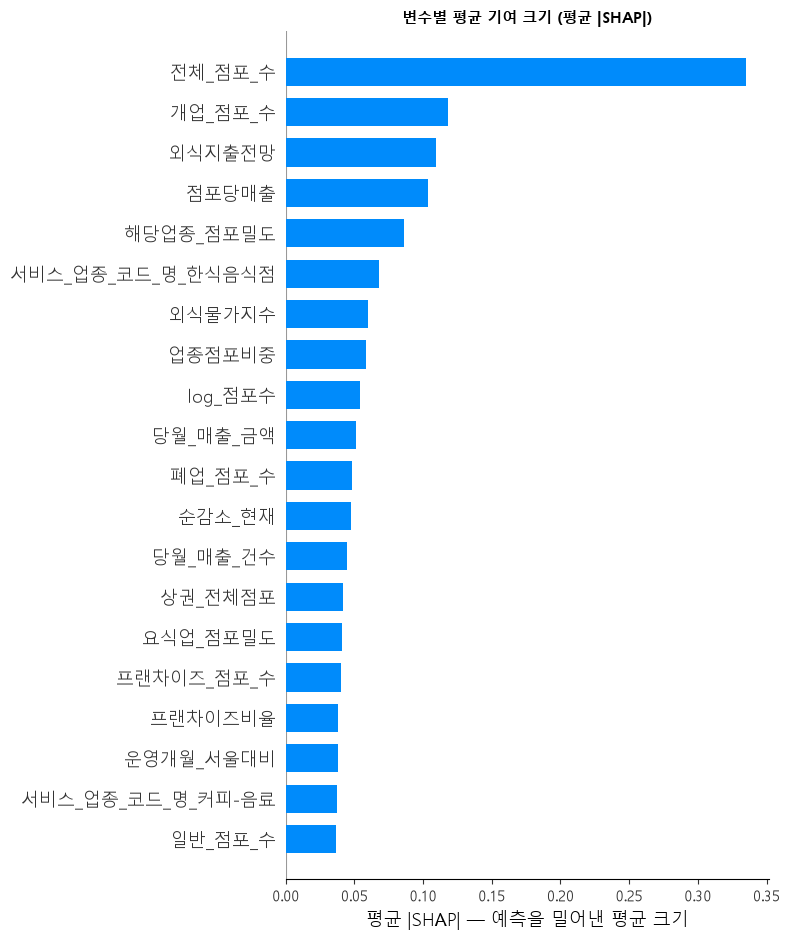

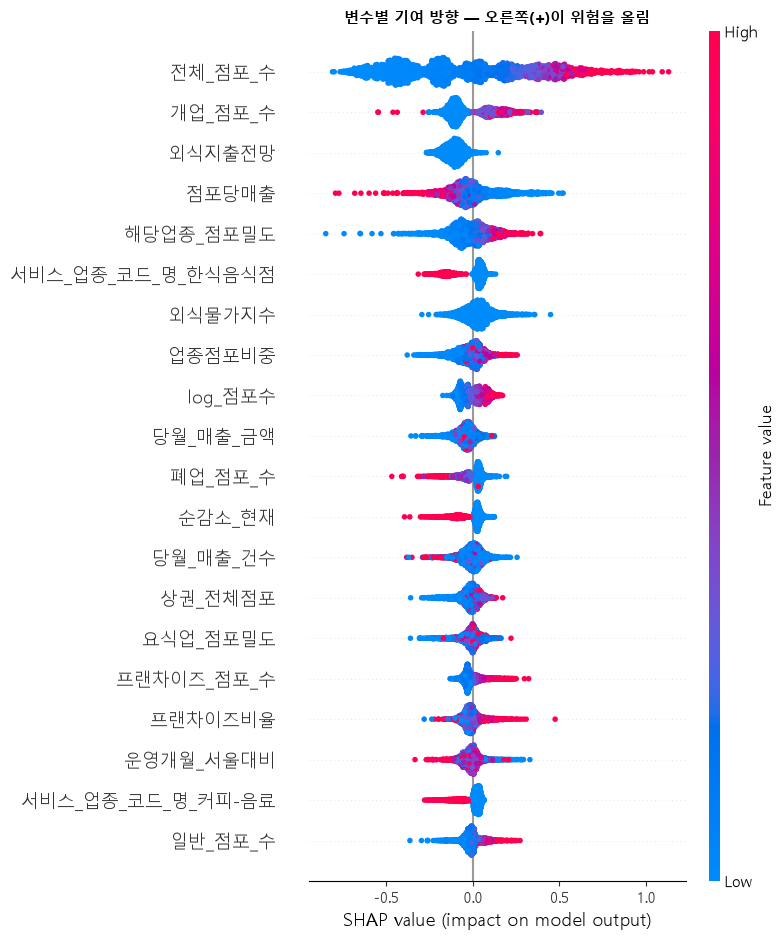

,평균 |SHAP|
전체_점포_수,0.3350
개업_점포_수,0.1181
외식지출전망,0.1096
점포당매출,0.1033
해당업종_점포밀도,0.0863
서비스_업종_코드_명_한식음식점,0.0679
외식물가지수,0.0600
업종점포비중,0.0583
log_점포수,0.0543
당월_매출_금액,0.0515


In [9]:
xgb_final = fitted["XGBoost"][0]
expl = shap.TreeExplainer(xgb_final)

samp = Xva.sample(min(3000, len(Xva)), random_state=SEED)
sv = expl.shap_values(samp)

# ① 막대 — 어느 변수가 얼마나 세게 작용하는가 (크기만)
plt.figure()
shap.summary_plot(sv, samp, plot_type="bar", max_display=20, show=False)
plt.title("변수별 평균 기여 크기 (평균 |SHAP|)", weight="bold", fontsize=11)
plt.xlabel("평균 |SHAP| — 예측을 밀어낸 평균 크기")
plt.tight_layout(); plt.savefig(FIG / "shap_bar.png", dpi=130, bbox_inches="tight"); plt.show()

# ② 벌떼 — 어느 방향으로 작용하는가 (부호와 값의 크기까지)
plt.figure()
shap.summary_plot(sv, samp, max_display=20, show=False)
plt.title("변수별 기여 방향 — 오른쪽(+)이 위험을 올림", weight="bold", fontsize=11)
plt.tight_layout(); plt.savefig(FIG / "shap_summary.png", dpi=130, bbox_inches="tight"); plt.show()

imp = (pd.Series(np.abs(sv).mean(axis=0), index=samp.columns)
       .sort_values(ascending=False).rename("평균 |SHAP|"))
display(imp.head(20).round(4).to_frame())

In [10]:
# 규모 계열과 그 밖의 변수 기여를 나누어 봄 — 3-1의 우려가 실제로 남아 있는지 확인
SIZE_LIKE = [c for c in samp.columns
             if any(k in c for k in ["점포수", "점포_수", "전체점포", "유동인구", "면적", "밀도"])]
share = imp[imp.index.isin(SIZE_LIKE)].sum() / imp.sum()
print(f"규모·밀도 계열이 차지하는 기여 비중 {share:.1%}")
print(f"그 밖의 변수 {1-share:.1%}")
print("\n규모 계열 상위")
display(imp[imp.index.isin(SIZE_LIKE)].head(8).round(4).to_frame())
print("규모 밖 상위")
display(imp[~imp.index.isin(SIZE_LIKE)].head(12).round(4).to_frame())

규모·밀도 계열이 차지하는 기여 비중 53.1%
그 밖의 변수 46.9%

규모 계열 상위


,평균 |SHAP|
전체_점포_수,0.3350
개업_점포_수,0.1181
해당업종_점포밀도,0.0863
log_점포수,0.0543
폐업_점포_수,0.0483
상권_전체점포,0.0418
요식업_점포밀도,0.0406
프랜차이즈_점포_수,0.0405


규모 밖 상위


,평균 |SHAP|
외식지출전망,0.1096
점포당매출,0.1033
서비스_업종_코드_명_한식음식점,0.0679
외식물가지수,0.0600
업종점포비중,0.0583
당월_매출_금액,0.0515
순감소_현재,0.0474
당월_매출_건수,0.0443
프랜차이즈비율,0.0381
운영개월_서울대비,0.0378


## 6-1. 두 확률로 상권을 네 유형으로 나눔

2단계 모형의 두 확률은 **서로 다른 것을 재기 때문에**, 곱해서 하나로 합치지 않고
**두 축으로 두면 상권의 성격이 갈림.** 이것이 단일 모형으로는 나오지 않는 결과임.

| 사건 확률 | 순감소 조건부 확률 | 유형 |
|---|---|---|
| 높음 | 높음 | **활발하게 변하면서 쇠퇴하는 상권** |
| 높음 | 낮음 | 활발하게 변하지만 성장·유지되는 상권 |
| 낮음 | 높음 | **정체되어 있지만 변화가 생기면 취약한 상권** |
| 낮음 | 낮음 | 안정적인 상권 |

**왜 이 구분이 필요한가** — 최종 위험도(두 확률의 곱)로 줄 세우면 사건 확률이 높은 쪽,
즉 **점포가 많은 상권이 앞으로 오고 작은 상권은 뒤로 밀림.** 그런데 뒤로 밀리는 쪽에
«조용하지만 한 번 흔들리면 버티지 못하는» 유형이 들어 있음. 순위 하나로 합치면 그 구분이 사라짐.
한쪽은 «회전이 빠른데 방향이 나쁜» 상권이고 다른 쪽은 «정체되어 있으나 취약한» 상권이므로
대응이 같을 수 없음.

**경계는 검증 분기의 중앙값으로 정함.** 테스트 분기의 분포를 보고 자르면 그 순간
테스트가 검증이 됨. 각 유형의 실제 순감소율을 붙여 이름이 데이터와 맞는지 확인함.


In [11]:
# 경계는 «검증 분기»의 중앙값 — 테스트를 보고 자르지 않기 위함
pe_va = m1.predict_proba(Xva)[:, 1]
pd_va = m2.predict_proba(Xva)[:, 1]
CUT_E, CUT_D = np.median(pe_va), np.median(pd_va)
print(f"검증 분기 중앙값으로 정한 경계  사건확률 {CUT_E:.4f} · 순감소조건부확률 {CUT_D:.4f}")

pe_te = m1.predict_proba(Xte)[:, 1]
pd_te = m2.predict_proba(Xte)[:, 1]

tq = d[m_te].copy()
tq["사건확률"] = pe_te
tq["순감소조건부확률"] = pd_te
tq["최종위험도"] = pe_te * pd_te
tq["사건_수준"] = np.where(pe_te >= CUT_E, "높음", "낮음")
tq["방향_수준"] = np.where(pd_te >= CUT_D, "높음", "낮음")

NAMES = {("높음", "높음"): "활발하게 변하면서 쇠퇴",
         ("높음", "낮음"): "활발하게 변하나 성장·유지",
         ("낮음", "높음"): "정체되어 있으나 변화 시 취약",
         ("낮음", "낮음"): "안정적"}
tq["유형"] = [NAMES[(a, b)] for a, b in zip(tq["사건_수준"], tq["방향_수준"])]

typ = (tq.groupby(["사건_수준", "방향_수준"], observed=True)
       .agg(칸수=("y", "size"), 실제순감소율=("y", "mean"),
            평균최종위험도=("최종위험도", "mean"), 평균점포=("전체_점포_수", "mean"),
            평균개업=("개업_점포_수", "mean"), 평균폐업=("폐업_점포_수", "mean")))
typ["유형"] = [NAMES[i] for i in typ.index]
typ["기저율대비"] = (typ["실제순감소율"] / tq["y"].mean()).round(2)
display(typ.round(3))
print(f"테스트 분기 기저율 {tq['y'].mean():.3f}")

검증 분기 중앙값으로 정한 경계  사건확률 0.4259 · 순감소조건부확률 0.5045


칸수  실제순감소율  평균최종위험도    평균점포   평균개업   평균폐업                유형  기저율대비
사건_수준 방향_수준                                                                      
낮음    낮음     1229   0.166    0.113   7.776  0.137  0.346               안정적   0.64
      높음     1535   0.192    0.166   7.550  0.263  0.163  정체되어 있으나 변화 시 취약   0.74
높음    낮음     1529   0.319    0.277  35.572  1.109  1.443    활발하게 변하나 성장·유지   1.23
      높음     1186   0.368    0.432  35.019  1.223  1.106      활발하게 변하면서 쇠퇴   1.42

테스트 분기 기저율 0.260


### 두 축의 이름이 데이터와 맞는가

두 확률은 각각 **다음 분기**를 예측하는 값이므로, 검산도 **다음 분기 실측**으로 해야 함.
현재 분기의 개업·폐업으로 검산하면 시점이 어긋나 엉뚱한 결론이 나옴.

| 축 | 예측하는 것 | 검산할 실측값 |
|---|---|---|
| 사건 확률 | 다음 분기에 개·폐업이 있는가 | `사건_다음` 의 실제 발생률 |
| 순감소 조건부 확률 | 사건이 났을 때 줄어드는 쪽인가 | 사건이 난 칸만 골라 본 `y` 의 비율 |

두 번째가 핵심임 — **분모를 «사건이 난 칸»으로 제한**해야 조건부 확률의 검산이 됨.
전체를 분모로 쓰면 사건 발생 여부가 섞여 들어감.


In [12]:
chk = tq.groupby(["사건_수준", "방향_수준"], observed=True).agg(
    칸수=("y", "size"),
    사건_실제발생률=("사건_다음", "mean"),
).reset_index()
cond = (tq[tq["사건_다음"] == 1].groupby(["사건_수준", "방향_수준"], observed=True)["y"]
        .agg(사건있던칸="size", 순감소_조건부실제="mean").reset_index())
chk = chk.merge(cond, on=["사건_수준", "방향_수준"])
chk["유형"] = [NAMES[(a, b)] for a, b in zip(chk["사건_수준"], chk["방향_수준"])]
chk["전체_순감소율"] = [tq.loc[(tq["사건_수준"] == a) & (tq["방향_수준"] == b), "y"].mean()
                    for a, b in zip(chk["사건_수준"], chk["방향_수준"])]
display(chk[["사건_수준", "방향_수준", "유형", "칸수", "사건_실제발생률",
             "사건있던칸", "순감소_조건부실제", "전체_순감소율"]].round(3))

hi_e = chk.loc[chk["사건_수준"] == "높음", "사건_실제발생률"].mean()
lo_e = chk.loc[chk["사건_수준"] == "낮음", "사건_실제발생률"].mean()
hi_d = chk.loc[chk["방향_수준"] == "높음", "순감소_조건부실제"].mean()
lo_d = chk.loc[chk["방향_수준"] == "낮음", "순감소_조건부실제"].mean()
print("검산")
print(f"  사건 실제발생률      사건확률 높음 {hi_e:.3f} vs 낮음 {lo_e:.3f}"
      f"  → {'이름과 일치' if hi_e > lo_e else '이름과 불일치'}")
print(f"  순감소 조건부 실제    방향 높음 {hi_d:.3f} vs 낮음 {lo_d:.3f}"
      f"  → {'이름과 일치' if hi_d > lo_d else '이름과 불일치'}")
print()
print("참고 — 현재 분기 개업·폐업 (라벨과 시점이 다르므로 검산에는 쓰지 않음)")
ref = typ.reset_index()[["유형", "평균개업", "평균폐업"]].copy()
ref["개폐업합"] = (ref["평균개업"] + ref["평균폐업"]).round(2)
ref["개업-폐업"] = (ref["평균개업"] - ref["평균폐업"]).round(2)
display(ref.round(2))

,사건_수준,방향_수준,유형,칸수,사건_실제발생률,사건있던칸,순감소_조건부실제,전체_순감소율
0,낮음,낮음,안정적,1229,0.343,422,0.483,0.166
1,낮음,높음,정체되어 있으나 변화 시 취약,1535,0.333,511,0.577,0.192
2,높음,낮음,활발하게 변하나 성장·유지,1529,0.733,1120,0.436,0.319
3,높음,높음,활발하게 변하면서 쇠퇴,1186,0.677,803,0.543,0.368


검산
  사건 실제발생률      사건확률 높음 0.705 vs 낮음 0.338  → 이름과 일치
  순감소 조건부 실제    방향 높음 0.560 vs 낮음 0.460  → 이름과 일치

참고 — 현재 분기 개업·폐업 (라벨과 시점이 다르므로 검산에는 쓰지 않음)


,유형,평균개업,평균폐업,개폐업합,개업-폐업
0,안정적,0.14,0.35,0.48,-0.21
1,정체되어 있으나 변화 시 취약,0.26,0.16,0.43,0.10
2,활발하게 변하나 성장·유지,1.11,1.44,2.55,-0.33
3,활발하게 변하면서 쇠퇴,1.22,1.11,2.33,0.12


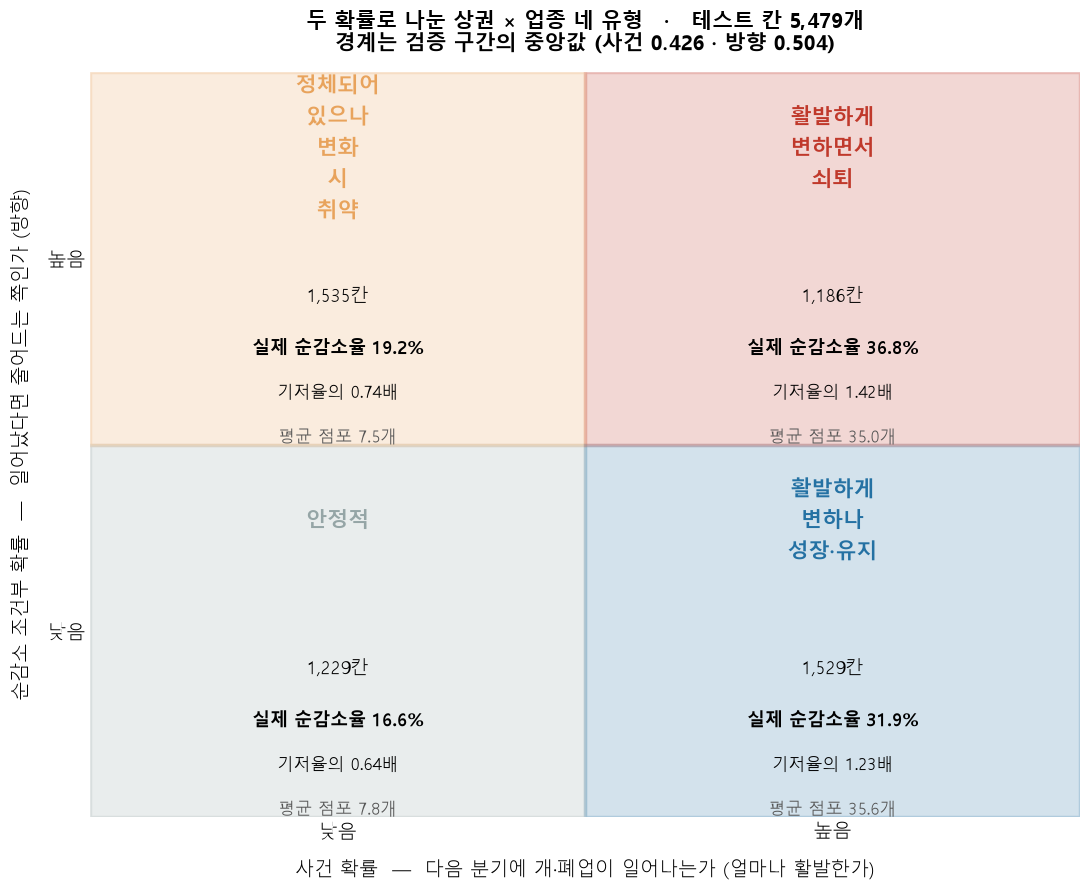

읽는 법 — 오른쪽으로 갈수록 변화가 활발하고, 위로 갈수록 변할 때 줄어드는 쪽임.
  오른쪽 위가 가장 위험하고 왼쪽 아래가 가장 안전함.
  대각선 두 칸은 최종 위험도가 중간이지만 성격이 정반대이므로 대응이 달라야 함.


In [13]:
# ── 사분면 도식 — 네 유형이 무엇인지 그림 하나로 ──
fig, ax = plt.subplots(figsize=(11, 9))
COL4 = {"활발하게 변하면서 쇠퇴": "#c0392b", "활발하게 변하나 성장·유지": "#2471a3",
        "정체되어 있으나 변화 시 취약": "#e8a35c", "안정적": "#95a5a6"}
POS = {("낮음", "낮음"): (0, 0), ("낮음", "높음"): (0, 1),
       ("높음", "낮음"): (1, 0), ("높음", "높음"): (1, 1)}

tq_ = typ.reset_index()
for _, r in tq_.iterrows():
    x, y = POS[(r["사건_수준"], r["방향_수준"])]
    nm = r["유형"]
    ax.add_patch(plt.Rectangle((x, y), 1, 1, facecolor=COL4[nm], alpha=.20,
                               edgecolor=COL4[nm], lw=2.5))
    cx, cy = x + .5, y + .5
    ax.text(cx, cy + .30, nm.replace(" ", "\n"), ha="center", va="center",
            fontsize=15, weight="bold", color=COL4[nm], linespacing=1.5)
    ax.text(cx, cy - .10, f"{int(r['칸수']):,}칸", ha="center", va="center", fontsize=13)
    ax.text(cx, cy - .24, f"실제 순감소율 {r['실제순감소율']:.1%}",
            ha="center", va="center", fontsize=13, weight="bold")
    ax.text(cx, cy - .36, f"기저율의 {r['기저율대비']:.2f}배", ha="center", va="center", fontsize=12)
    ax.text(cx, cy - .48, f"평균 점포 {r['평균점포']:.1f}개", ha="center", va="center",
            fontsize=12, color="#555")

ax.set_xlim(0, 2); ax.set_ylim(0, 2)
ax.set_xticks([.5, 1.5]); ax.set_xticklabels(["낮음", "높음"], fontsize=14)
ax.set_yticks([.5, 1.5]); ax.set_yticklabels(["낮음", "높음"], fontsize=14)
ax.set_xlabel("사건 확률  —  다음 분기에 개·폐업이 일어나는가 (얼마나 활발한가)",
              fontsize=13.5, labelpad=12)
ax.set_ylabel("순감소 조건부 확률  —  일어났다면 줄어드는 쪽인가 (방향)",
              fontsize=13.5, labelpad=12)
ax.set_title(f"두 확률로 나눈 상권 × 업종 네 유형   ·   테스트 칸 {len(tq):,}개\n"
             f"경계는 검증 구간의 중앙값 (사건 {CUT_E:.3f} · 방향 {CUT_D:.3f})",
             fontsize=15, weight="bold", pad=16)
for sp in ax.spines.values(): sp.set_visible(False)
ax.tick_params(length=0)
plt.tight_layout(); plt.savefig(FIG / "two_stage_quadrant.png", dpi=140); plt.show()

print("읽는 법 — 오른쪽으로 갈수록 변화가 활발하고, 위로 갈수록 변할 때 줄어드는 쪽임.")
print("  오른쪽 위가 가장 위험하고 왼쪽 아래가 가장 안전함.")
print("  대각선 두 칸은 최종 위험도가 중간이지만 성격이 정반대이므로 대응이 달라야 함.")

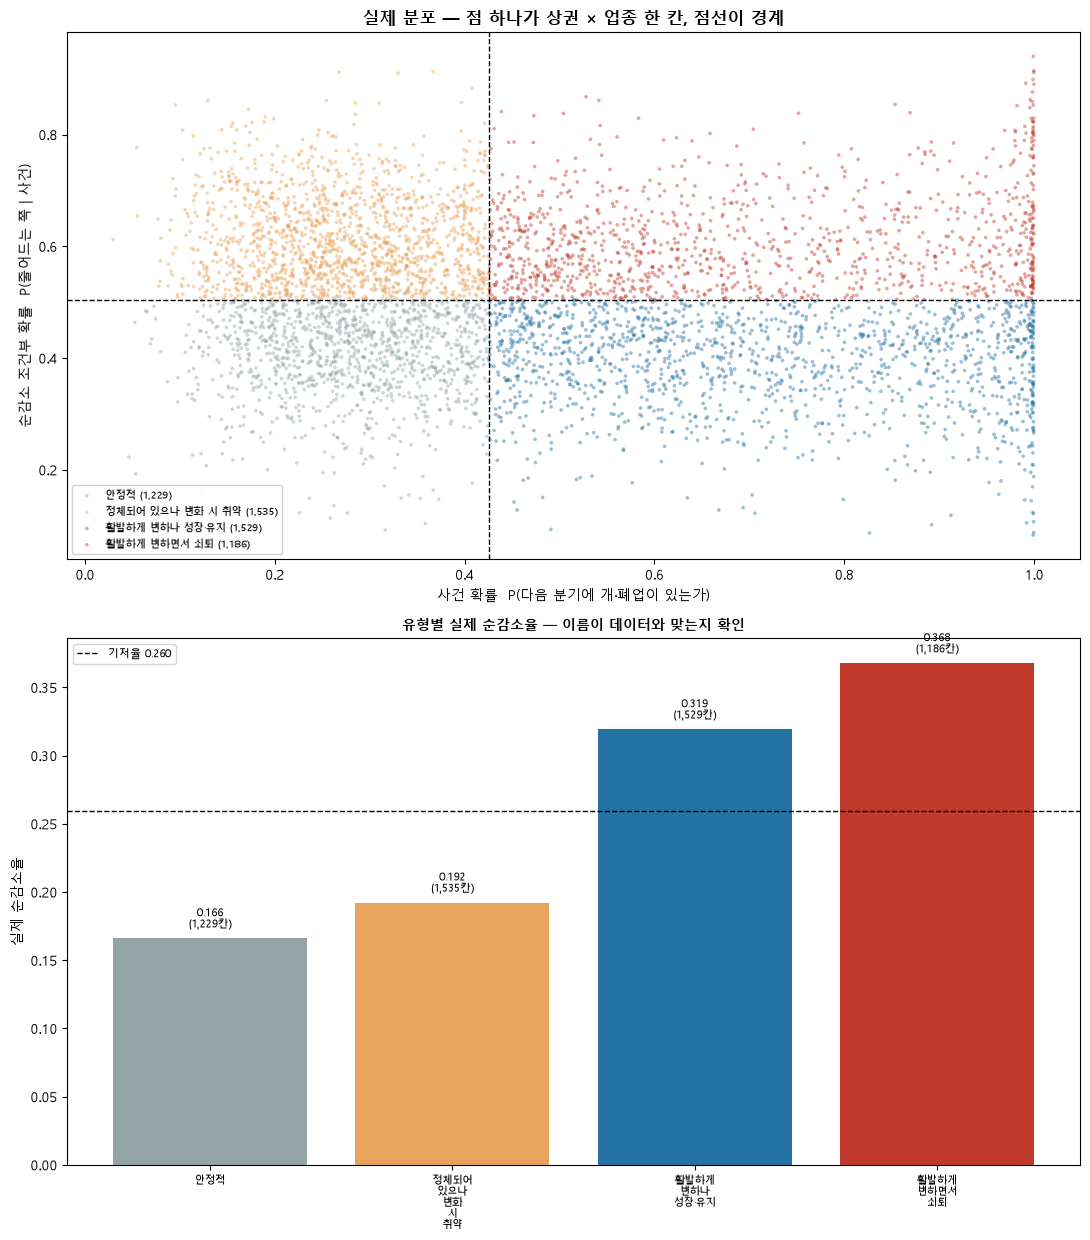

가운데 두 유형 — 최종 위험도로 줄 세우면 어떻게 되는가


,유형,칸수,평균최종위험도,실제순감소율,평균점포
1,정체되어 있으나 변화 시 취약,1535,0.166,0.192,7.550
2,활발하게 변하나 성장·유지,1529,0.277,0.319,35.572


최종 위험도로 줄 세우면  «활발하게 변하나 성장·유지» 0.277  >  «정체되어 있으나 변화 시 취약» 0.166
평균 점포 수는           35.6개  vs  7.5개  (4.7배)

→ 곱 하나로 줄 세우면 «점포가 많은 쪽»이 앞에 오고, 작은 상권은 뒤로 밀림.
  그런데 뒤로 밀린 쪽이 «조용하지만 한 번 흔들리면 버티지 못하는» 유형임.
  칸 수가 비슷한데 성격이 정반대이므로, 하나의 순위로 합치면 이 구분이 사라짐.
  두 확률을 두 축으로 남겨 두어야 «어느 쪽에 어떤 대응이 필요한가»를 말할 수 있음.


In [14]:
fig, ax = plt.subplots(2, 1, figsize=(11, 12.5))

COL4 = {"활발하게 변하면서 쇠퇴": "#c0392b", "활발하게 변하나 성장·유지": "#2471a3",
        "정체되어 있으나 변화 시 취약": "#e8a35c", "안정적": "#95a5a6"}
for nm, g in tq.groupby("유형", observed=True):
    ax[0].scatter(g["사건확률"], g["순감소조건부확률"], s=7, alpha=.45,
                  c=COL4[nm], label=f"{nm} ({len(g):,})", edgecolors="none")
ax[0].axvline(CUT_E, ls="--", c="k", lw=1); ax[0].axhline(CUT_D, ls="--", c="k", lw=1)
ax[0].set_xlabel("사건 확률  P(다음 분기에 개·폐업이 있는가)")
ax[0].set_ylabel("순감소 조건부 확률  P(줄어드는 쪽 | 사건)")
ax[0].set_title("실제 분포 — 점 하나가 상권 × 업종 한 칸, 점선이 경계", weight="bold", fontsize=12)
ax[0].legend(fontsize=7.5, loc="lower left", framealpha=.9)

order4 = ["안정적", "정체되어 있으나 변화 시 취약", "활발하게 변하나 성장·유지", "활발하게 변하면서 쇠퇴"]
vals = [tq.loc[tq["유형"] == n, "y"].mean() for n in order4]
cnts = [int((tq["유형"] == n).sum()) for n in order4]
bars = ax[1].bar(range(4), vals, color=[COL4[n] for n in order4])
ax[1].axhline(tq["y"].mean(), ls="--", c="k", lw=1, label=f"기저율 {tq['y'].mean():.3f}")
for i_, (b, c_) in enumerate(zip(bars, cnts)):
    ax[1].text(i_, b.get_height() + .008, f"{b.get_height():.3f}\n({c_:,}칸)",
               ha="center", fontsize=8)
ax[1].set_xticks(range(4))
ax[1].set_xticklabels([n.replace(" ", "\n") for n in order4], fontsize=7.5)
ax[1].set_ylabel("실제 순감소율"); ax[1].legend(fontsize=8)
ax[1].set_title("유형별 실제 순감소율 — 이름이 데이터와 맞는지 확인", weight="bold", fontsize=10)
plt.tight_layout(); plt.savefig(FIG / "two_stage_types.png", dpi=140); plt.show()

print("가운데 두 유형 — 최종 위험도로 줄 세우면 어떻게 되는가")
mid = typ.reset_index()
mid = mid[((mid["사건_수준"] == "높음") & (mid["방향_수준"] == "낮음")) |
          ((mid["사건_수준"] == "낮음") & (mid["방향_수준"] == "높음"))]
display(mid[["유형", "칸수", "평균최종위험도", "실제순감소율", "평균점포"]].round(3))
if len(mid) == 2:
    m2_ = mid.sort_values("평균최종위험도")
    lo_t, hi_t = m2_.iloc[0], m2_.iloc[1]
    print(f"최종 위험도로 줄 세우면  «{hi_t['유형']}» {hi_t['평균최종위험도']:.3f}"
          f"  >  «{lo_t['유형']}» {lo_t['평균최종위험도']:.3f}")
    print(f"평균 점포 수는           {hi_t['평균점포']:.1f}개  vs  {lo_t['평균점포']:.1f}개"
          f"  ({hi_t['평균점포']/max(lo_t['평균점포'],1e-9):.1f}배)")
    print()
    print("→ 곱 하나로 줄 세우면 «점포가 많은 쪽»이 앞에 오고, 작은 상권은 뒤로 밀림.")
    print("  그런데 뒤로 밀린 쪽이 «조용하지만 한 번 흔들리면 버티지 못하는» 유형임.")
    print("  칸 수가 비슷한데 성격이 정반대이므로, 하나의 순위로 합치면 이 구분이 사라짐.")
    print("  두 확률을 두 축으로 남겨 두어야 «어느 쪽에 어떤 대응이 필요한가»를 말할 수 있음.")

In [15]:
# 유형별 대표 상권 — 발표에서 «어디가 어떤 유형인가»를 보여주기 위함
rep = (tq.groupby("유형", observed=True)
       .apply(lambda g: g.nlargest(4, "전체_점포_수")[
           ["자치구", "상권_코드_명", "상권유형", "서비스_업종_코드_명", "전체_점포_수",
            "개업_점포_수", "폐업_점포_수", "사건확률", "순감소조건부확률", "y"]],
              include_groups=False)
       .round(3))
display(rep)

print("상권유형 × 네 유형 — 어느 유형이 어디에 몰려 있는가 (행 안에서의 비중)")
comp = pd.crosstab(tq["상권유형"], tq["유형"], normalize="index").round(3)
display(comp)
cnt = pd.crosstab(tq["상권유형"], tq["유형"])
display(cnt)
for t_ in comp.index:
    top_ = comp.loc[t_].idxmax()
    print(f"  {t_:6} {int(cnt.loc[t_].sum()):>6,}칸 · 최다 유형 «{top_}» {comp.loc[t_, top_]:.1%}"
          f" · 실제 순감소율 {tq.loc[tq['상권유형']==t_, 'y'].mean():.3f}")

자치구                 상권_코드_명  상권유형 서비스_업종_코드_명  전체_점포_수  개업_점포_수  폐업_점포_수   사건확률  순감소조건부확률  y
유형                                                                                                                   
안정적              64235   양천구                   목2동시장  전통시장       한식음식점     36.0      2.0      0.0  0.356     0.377  0
                 9493    중랑구                  장스여성병원  골목상권       한식음식점     24.0      0.0      0.0  0.317     0.352  0
                 59048    중구                    약수시장  전통시장       한식음식점     23.0      0.0      0.0  0.355     0.332  1
                 443     종로구              종로·청계 관광특구  관광특구       치킨전문점     22.0      0.0      3.0  0.267     0.358  0
정체되어 있으나 변화 시 취약 55272   강남구                     코엑스  발달상권       한식음식점     36.0      0.0      0.0  0.405     0.551  0
                 44065  서대문구                    충정로역  발달상권       한식음식점     34.0      1.0      1.0  0.425     0.512  1
                 30801   서초구          양재역 8번(양재동우체국)  골목상권     호프-간이주점     26.0      1.0      1.0  0.422     0.762  0
                 31218   강남구                싸리고개근린공원  골목상권       분식전문점     26.0      0.0      0.0  0.136     0.708  0
활발하게 변하나 성장·유지   131      중구  명동 남대문 북창동 다동 무교동 관광특구  관광특구       한식음식점    671.0     18.0     20.0  0.999     0.302  1
                 47381   금천구                 가산디지털단지  발달상권       한식음식점    534.0     28.0     16.0  1.000     0.357  1
                 48771  영등포구               여의도역(여의도)  발달상권       한식음식점    493.0     14.0      8.0  0.999     0.286  0
                 52362   서초구                     강남역  발달상권       한식음식점    484.0     12.0     14.0  1.000     0.387  0
활발하게 변하면서 쇠퇴     371     종로구              종로·청계 관광특구  관광특구       한식음식점    506.0     15.0     28.0  0.999     0.605  1
                 46192   강서구                 발산역(마곡)  발달상권       한식음식점    390.0     14.0     17.0  1.000     0.744  0
                 53234   강남구                     역삼역  발달상권       한식음식점    389.0     22.0     26.0  0.999     0.829  1
                 47489   금천구                 가산디지털단지  발달상권       커피-음료    322.0      9.0     14.0  0.999     0.669  0

상권유형 × 네 유형 — 어느 유형이 어디에 몰려 있는가 (행 안에서의 비중)


유형,안정적,정체되어 있으나 변화 시 취약,활발하게 변하나 성장·유지,활발하게 변하면서 쇠퇴
상권유형,,,,
골목상권,0.248,0.347,0.238,0.167
관광특구,0.052,0.086,0.397,0.466
발달상권,0.191,0.166,0.345,0.298
전통시장,0.236,0.335,0.256,0.173


유형,안정적,정체되어 있으나 변화 시 취약,활발하게 변하나 성장·유지,활발하게 변하면서 쇠퇴
상권유형,,,,
골목상권,687,963,659,463
관광특구,3,5,23,27
발달상권,362,316,655,566
전통시장,177,251,192,130


  골목상권    2,772칸 · 최다 유형 «정체되어 있으나 변화 시 취약» 34.7% · 실제 순감소율 0.231
  관광특구       58칸 · 최다 유형 «활발하게 변하면서 쇠퇴» 46.6% · 실제 순감소율 0.448
  발달상권    1,899칸 · 최다 유형 «활발하게 변하나 성장·유지» 34.5% · 실제 순감소율 0.305
  전통시장      750칸 · 최다 유형 «정체되어 있으나 변화 시 취약» 33.5% · 실제 순감소율 0.235


## 6-3. 2단계 모형을 SHAP으로 열어 보기 — 규모를 빼면 무엇이 남는가

5장의 단일 모형 SHAP은 규모·밀도 계열이 절반을 넘게 차지함. 그래서 «무엇이 위험을 만드는가»에
「점포가 많으면 위험하다」밖에 답하지 못함. 그런데 그건 위험이 아니라 **사건이 일어날 크기**임.

2단계 모형은 이 문제를 구조적으로 분리하므로, **단계별로 따로 SHAP을 내면** 답이 갈라짐.
두 모형 모두 XGBoost이므로 `TreeExplainer`가 각각에 그대로 적용됨.

```
1단계 SHAP   무엇이 «사건»을 일으키는가          →  규모 변수가 상위를 채울 것
2단계 SHAP   사건이 났을 때 무엇이 «줄어드는 쪽»으로 미는가  →  규모를 통제한 위험 요인
```

**2단계 SHAP이 원래 묻고 싶었던 것에 대한 답임.** 규모가 이미 조건으로 걸려 있으므로,
거기서 상위에 오는 변수는 «크기와 무관하게 위험을 만드는 것»임.

> 곱을 한 장의 SHAP으로 합치는 것은 되지 않음 — SHAP은 기여를 **더해서** 설명하는데
> 최종 점수가 두 확률의 **곱**이기 때문임. 다만 로그를 취하면 가법이 되므로
> (`log P = log p₁ + log p₂`) 단계별 SHAP을 변수마다 더해 합산 기여도를 낼 수는 있음.
> 해석이 «로그확률 기여»가 되어 직관성이 떨어지므로 아래에서는 보조로만 냄.


In [16]:
expl1 = shap.TreeExplainer(m1)
expl2 = shap.TreeExplainer(m2)
samp2 = Xva.sample(min(3000, len(Xva)), random_state=SEED)
sv1 = expl1.shap_values(samp2)
sv2 = expl2.shap_values(samp2)

imp1 = pd.Series(np.abs(sv1).mean(axis=0), index=samp2.columns).sort_values(ascending=False)
imp2 = pd.Series(np.abs(sv2).mean(axis=0), index=samp2.columns).sort_values(ascending=False)

SIZE_LIKE2 = [c for c in samp2.columns
              if any(k in c for k in ["점포수", "점포_수", "전체점포", "유동인구", "면적", "밀도"])]
sh1 = imp1[imp1.index.isin(SIZE_LIKE2)].sum() / imp1.sum()
sh2 = imp2[imp2.index.isin(SIZE_LIKE2)].sum() / imp2.sum()

print("규모·밀도 계열이 차지하는 기여 비중")
print(f"  단일 모형          {share:.1%}")
print(f"  1단계 P(사건)       {sh1:.1%}")
print(f"  2단계 P(순감소|사건)  {sh2:.1%}   ← 규모를 조건으로 걸었을 때 남는 몫")
print()
cmp_tab = pd.DataFrame({"1단계 |SHAP|": imp1, "2단계 |SHAP|": imp2}).head(18)
cmp_tab["1단계 순위"] = imp1.rank(ascending=False).astype(int)
cmp_tab["2단계 순위"] = imp2.rank(ascending=False).astype(int)
display(cmp_tab.round(4))

규모·밀도 계열이 차지하는 기여 비중
  단일 모형          53.1%
  1단계 P(사건)       65.4%
  2단계 P(순감소|사건)  38.3%   ← 규모를 조건으로 걸었을 때 남는 몫



,1단계 |SHAP|,2단계 |SHAP|,1단계 순위,2단계 순위
log_면적,0.0092,0.0091,42,47
log_요식업밀도,0.0140,0.0196,38,32
log_유동인구,0.0190,0.0138,33,38
log_점포당매출,0.0183,0.0253,34,28
log_점포수,0.1302,0.0131,2,39
log_해당업종밀도,0.0092,0.0117,43,42
개업_점포_수,0.0633,0.1031,7,3
관공서_수,0.0047,0.0072,58,49
극장_수,0.0051,0.0032,57,63
당월_매출_건수,0.0514,0.0561,11,11


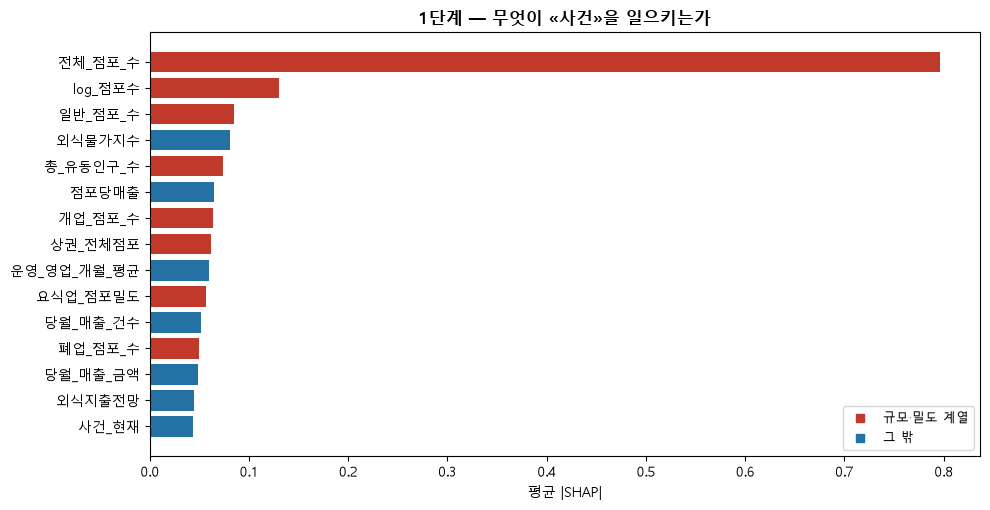

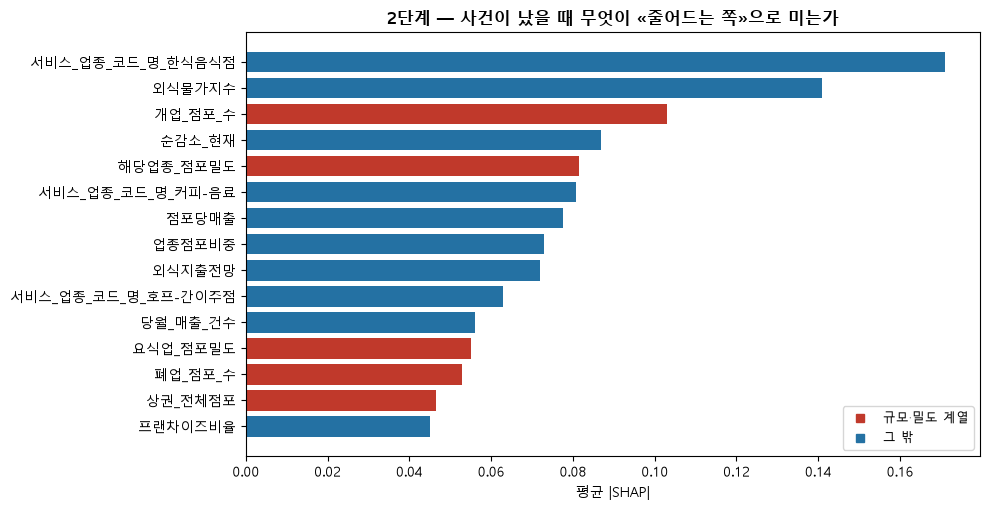

2단계 상위 — 규모 계열을 뺀 목록 (규모를 조건으로 걸었을 때의 위험 요인)


,2단계 평균 |SHAP|
서비스_업종_코드_명_한식음식점,0.1710
외식물가지수,0.1408
순감소_현재,0.0869
서비스_업종_코드_명_커피-음료,0.0807
점포당매출,0.0775
업종점포비중,0.0730
외식지출전망,0.0720
서비스_업종_코드_명_호프-간이주점,0.0628
당월_매출_건수,0.0561
프랜차이즈비율,0.0450



보조 — 두 단계 기여를 더한 순위 (로그확률 기준, 상위 10)


,합산 |SHAP|
전체_점포_수,0.8361
외식물가지수,0.2215
서비스_업종_코드_명_한식음식점,0.2110
개업_점포_수,0.1664
log_점포수,0.1433
점포당매출,0.1419
총_유동인구_수,0.1184
해당업종_점포밀도,0.1171
외식지출전망,0.1163
요식업_점포밀도,0.1119


합산은 «두 단계 중 어디서든 많이 쓰인 변수»를 보여 줌.
규모 변수는 1단계에서, 그 밖의 변수는 2단계에서 올라오는 구조가 그대로 나타남.


In [17]:
for imp_, ttl, fn in [(imp1, "1단계 — 무엇이 «사건»을 일으키는가", "shap_stage1.png"),
                      (imp2, "2단계 — 사건이 났을 때 무엇이 «줄어드는 쪽»으로 미는가", "shap_stage2.png")]:
    fig, a_ = plt.subplots(figsize=(10, 5.2))
    top = imp_.head(15)[::-1]
    cols = ["#c0392b" if c in SIZE_LIKE2 else "#2471a3" for c in top.index]
    a_.barh(range(len(top)), top.values, color=cols)
    a_.set_yticks(range(len(top))); a_.set_yticklabels(top.index, fontsize=10)
    a_.set_xlabel("평균 |SHAP|"); a_.set_title(ttl, weight="bold", fontsize=12)
    a_.plot([], [], "s", c="#c0392b", label="규모·밀도 계열")
    a_.plot([], [], "s", c="#2471a3", label="그 밖")
    a_.legend(fontsize=9, loc="lower right")
    plt.tight_layout(); plt.savefig(FIG / fn, dpi=130); plt.show()

print("2단계 상위 — 규모 계열을 뺀 목록 (규모를 조건으로 걸었을 때의 위험 요인)")
display(imp2[~imp2.index.isin(SIZE_LIKE2)].head(12).round(4).to_frame("2단계 평균 |SHAP|"))

# 보조 — 로그 가법 결합
p1v = np.clip(m1.predict_proba(samp2)[:, 1], 1e-9, 1)
p2v = np.clip(m2.predict_proba(samp2)[:, 1], 1e-9, 1)
comb = pd.Series(np.abs(sv1).mean(axis=0) + np.abs(sv2).mean(axis=0),
                 index=samp2.columns).sort_values(ascending=False)
print("\n보조 — 두 단계 기여를 더한 순위 (로그확률 기준, 상위 10)")
display(comb.head(10).round(4).to_frame("합산 |SHAP|"))
print("합산은 «두 단계 중 어디서든 많이 쓰인 변수»를 보여 줌.")
print("규모 변수는 1단계에서, 그 밖의 변수는 2단계에서 올라오는 구조가 그대로 나타남.")

## 6-4. 후보 변수 4종 — 넣어 보고 판정

EDA 6장에서 통과·탈락한 변수를 모델 안에서 다시 확인함.

| 변수 | EDA 판정 | 여기서 확인할 것 |
|---|---|---|
| `운영_영업_개월_평균` | 통과 | SHAP 기여가 실제로 있는가 |
| `운영개월_서울대비` | 통과 | 위와 중복인가 |
| `외식물가지수` · `외식지출전망` | 상수 | 테스트 분기 안에서 기여가 0인가 |

**전국 지표의 SHAP이 0에 가깝게 나오는 것이 예상 결과임.** 한 분기 안에서 값이 하나뿐이면
트리가 그 변수로 칸을 나눌 수 없기 때문임. 이것이 «분기 안 상수는 순위를 못 바꾼다»의 실물임.


In [18]:
NEW_VARS = ["운영_영업_개월_평균", "운영개월_서울대비", "외식물가지수", "외식지출전망"]
NEW_VARS = [c for c in NEW_VARS if c in samp.columns]

print("테스트 칸(2025Q4 시점) 안에서 각 변수가 갖는 서로 다른 값의 개수")
one_q = d[m_te]
for c_ in NEW_VARS + ["전체_점포_수"]:
    print(f"  {c_:22} {one_q[c_].nunique():>6}개")
print()

tab = pd.DataFrame({
    "평균 |SHAP|": [float(np.abs(sv[:, samp.columns.get_loc(c_)]).mean()) for c_ in NEW_VARS],
    "전체 기여 중 비중": [float(np.abs(sv[:, samp.columns.get_loc(c_)]).mean()
                              / np.abs(sv).mean(axis=0).sum()) for c_ in NEW_VARS],
    "SHAP 순위": [int(imp.index.get_loc(c_)) + 1 for c_ in NEW_VARS],
}, index=NEW_VARS)
display(tab.round(5))
print(f"(전체 {len(imp)}개 변수 중 순위)\n")

for c_ in NEW_VARS:
    v = float(np.abs(sv[:, samp.columns.get_loc(c_)]).mean())
    nq = one_q[c_].nunique()
    if nq == 1:
        print(f"  {c_:22} 테스트 분기 안 값 1개 · 평균|SHAP| {v:.5f} → 순위 기여 불가")
    else:
        print(f"  {c_:22} 테스트 분기 안 값 {nq}개 · 평균|SHAP| {v:.5f}")
print()
print("전국 지표는 «학습 구간의 분기를 구분하는 용도»로만 쓰이고, 테스트 분기에서는")
print("모든 칸이 같은 값을 받아 어떤 칸이 더 위험한지 가려내지 못함.")
print("SHAP 값이 0이 아니어도 그것은 분기 사이의 수준 차이를 반영한 것이고,")
print("한 분기 안의 순위에는 상수를 더한 것과 같아 순서를 바꾸지 않음.")

테스트 칸(2025Q4 시점) 안에서 각 변수가 갖는 서로 다른 값의 개수
  운영_영업_개월_평균               132개
  운영개월_서울대비                 132개
  외식물가지수                      1개
  외식지출전망                      1개
  전체_점포_수                   188개



,평균 |SHAP|,전체 기여 중 비중,SHAP 순위
운영_영업_개월_평균,0.03150,0.01525,26
운영개월_서울대비,0.03776,0.01828,18
외식물가지수,0.05996,0.02902,7
외식지출전망,0.10957,0.05304,3


(전체 92개 변수 중 순위)

  운영_영업_개월_평균            테스트 분기 안 값 132개 · 평균|SHAP| 0.03150
  운영개월_서울대비              테스트 분기 안 값 132개 · 평균|SHAP| 0.03776
  외식물가지수                 테스트 분기 안 값 1개 · 평균|SHAP| 0.05996 → 순위 기여 불가
  외식지출전망                 테스트 분기 안 값 1개 · 평균|SHAP| 0.10957 → 순위 기여 불가

전국 지표는 «학습 구간의 분기를 구분하는 용도»로만 쓰이고, 테스트 분기에서는
모든 칸이 같은 값을 받아 어떤 칸이 더 위험한지 가려내지 못함.
SHAP 값이 0이 아니어도 그것은 분기 사이의 수준 차이를 반영한 것이고,
한 분기 안의 순위에는 상수를 더한 것과 같아 순서를 바꾸지 않음.


---
# 7. 테스트 최종 평가 — 2026Q1 결과

여기서 처음으로 테스트 분기를 씀. 임계값은 **검증 분기에서 정한 것**을 그대로 옮김.
테스트 결과를 보고 임계값을 다시 만지면 테스트가 검증이 되어 버림.


In [19]:
thr_q = 1 - yva.mean()                        # 검증에서 정한 «상위 몇 %를 위험으로 찍는가»
s_te = score_of(xgb_final, Xte)
thr = np.quantile(s_va, thr_q)                # 검증 점수 분포에서 뽑은 절대 임계값
pred_te = (s_te >= thr).astype(int)

cm = confusion_matrix(yte, pred_te)
res = {"AP": average_precision_score(yte, s_te),
       "ROC-AUC": roc_auc_score(yte, s_te),
       "정밀도": precision_score(yte, pred_te, zero_division=0),
       "재현율": recall_score(yte, pred_te),
       "F1": f1_score(yte, pred_te),
       "정확도": accuracy_score(yte, pred_te),
       "Lift": precision_score(yte, pred_te, zero_division=0) / yte.mean()}
display(pd.Series(res).round(3).to_frame("테스트(2026Q1 결과)"))
print(pd.DataFrame(cm, index=["실제 0", "실제 1"], columns=["예측 0", "예측 1"]).to_string())
print(f"\n기저율 {yte.mean():.1%} · 위험으로 찍은 칸 {int(pred_te.sum()):,}개")

bl_te = BASE[BASE["분기"] == "테스트(2026Q1 결과)"].set_index("방법")["Lift"]
print("\n기준선 대비")
for k_, v_ in bl_te.items():
    print(f"  {k_:22} Lift {v_:.3f}")
print(f"  {'XGBoost':22} Lift {res['Lift']:.3f}")

,테스트(2026Q1 결과)
AP,0.399
ROC-AUC,0.648
정밀도,0.395
재현율,0.372
F1,0.384
정확도,0.689
Lift,1.522


      예측 0  예측 1
실제 0  3245   811
실제 1   893   530

기저율 26.0% · 위험으로 찍은 칸 1,341개

기준선 대비
  무작위(전부 위험)             Lift 1.000
  직전 분기                  Lift 1.199
  상권변화지표(HL)             Lift 0.937
  점포 수(상위 1,285칸)        Lift 1.645
  XGBoost                Lift 1.522


## 7-1. 모델과 1위 모델·기준선을 같은 분기에 나란히 놓기

3장에서 XGBoost가 검증 AP 1위가 아니었으므로, **테스트 분기에서 셋을 함께** 재 봄.
2단계 모형(`P(사건) × P(순감소 | 사건)`)도 같은 표에 넣음.


In [20]:
def eval_scores(sc, name, sc_va):
    """임계값은 «검증 점수 분포»에서 뽑음 — 테스트를 보고 정하지 않기 위함"""
    pred = (sc >= np.quantile(sc_va, 1 - yva.mean())).astype(int)
    return {"방법": name, "AP": average_precision_score(yte, sc),
            "ROC-AUC": roc_auc_score(yte, sc),
            "정밀도": precision_score(yte, pred, zero_division=0),
            "재현율": recall_score(yte, pred),
            "Lift": precision_score(yte, pred, zero_division=0) / yte.mean()}

rows_te = [eval_scores(s_te, "XGBoost (채택)", s_va)]
top_mdl, top_mode = fitted[TOP]
if TOP != BEST:
    sv_top = score_of(top_mdl, Xva_f if top_mode == "fill" else Xva)
    st_top = score_of(top_mdl, Xte_f if top_mode == "fill" else Xte)
    rows_te.append(eval_scores(st_top, f"{TOP} (검증 AP 1위)", sv_top))
rows_te.append(eval_scores(m1.predict_proba(Xte)[:, 1] * m2.predict_proba(Xte)[:, 1],
                           "2단계 모형", s_two))

FINAL = pd.DataFrame(rows_te).set_index("방법").round(3)
# 기준선도 같은 표에 (점수가 아니라 규칙이므로 Lift만 옮겨 옴)
for nm in ["직전 분기", "점포 수(상위 1,285칸)", "상권변화지표(HL)"]:
    if nm in bl_te.index:
        FINAL.loc[f"[기준선] {nm}"] = [np.nan, np.nan, np.nan, np.nan, bl_te[nm]]
display(FINAL)

best_lift = FINAL.loc["XGBoost (채택)", "Lift"]
size_lift = bl_te.get("점포 수(상위 1,285칸)", np.nan)
print(f"모델 Lift {best_lift:.3f}  vs  «점포 수» 기준선 Lift {size_lift:.3f}")
if best_lift < size_lift:
    print("→ 이 작동점에서는 «점포 수» 규칙이 더 높음. 4장의 구간별 표와 7-2의 작동점별 표를")
    print("  함께 읽어야 해석이 됨.")

,AP,ROC-AUC,정밀도,재현율,Lift
방법,,,,,
XGBoost (채택),0.399,0.648,0.395,0.372,1.522
랜덤포레스트 (검증 AP 1위),0.413,0.664,0.422,0.404,1.627
2단계 모형,0.407,0.653,0.413,0.382,1.592
[기준선] 직전 분기,NaN,NaN,NaN,NaN,1.199
"[기준선] 점포 수(상위 1,285칸)",NaN,NaN,NaN,NaN,1.645
[기준선] 상권변화지표(HL),NaN,NaN,NaN,NaN,0.937


모델 Lift 1.522  vs  «점포 수» 기준선 Lift 1.645
→ 이 작동점에서는 «점포 수» 규칙이 더 높음. 4장의 구간별 표와 7-2의 작동점별 표를
  함께 읽어야 해석이 됨.


## 7-2. 몇 칸을 위험으로 찍을 것인가 — 작동점을 바꿔서 다시 봄

위 표는 «기저율과 같은 비율(약 23%, 1,285칸)을 위험으로 찍는» 설정에서 잰 것임.
그런데 **예측 모델에서 전체의 23%에 경보를 울리는 운영은 없음.** 손이 닿는 수십~수백 곳을 찍음.

작동점을 바꿔 가며 정밀도를 다시 재 봄. 이 표가 실제 운영 조건에 더 가까움.

**작동점은 검증 분기에서 고름.** 테스트 결과를 본 뒤 «잘 나오는 지점»을 고르면
그 순간 테스트가 검증이 되어 버림. 검증에서 정한 `k`를 테스트에 그대로 옮겨 쓰고,
테스트 표의 다른 `k` 값은 참고로만 함께 보임.

**정밀도와 재현율을 함께 봐야 함.** 찍는 개수를 고정하면 두 지표는 서로의 상수배가 되므로
«어느 방법이 더 나은가»를 가리는 데는 둘 중 하나만 봐도 순서가 같음.
그러나 **«얼마나 놓치는가»는 재현율만 답함.** 상위 소수를 찍으면 정밀도는 높아지지만
실제 위험 칸의 대부분을 지나치게 되므로, 운영에서 몇 곳을 볼 수 있는지와 함께 읽어야 함.


In [21]:
# 작동점은 «검증» 분기에서 고름 — 테스트를 보고 고르면 테스트가 검증이 되어 버림
rows_v = []
for k in [50, 100, 200, 300, 500, 800, 1285, 2000]:
    iv = np.argsort(-s_va, kind="stable")[:k]
    rows_v.append({"위험으로 찍은 수": k, "검증 정밀도": yva.values[iv].mean(),
                   "검증 재현율": yva.values[iv].sum() / int(yva.sum()),
                   "검증 ÷ 기저율": yva.values[iv].mean() / yva.mean()})
VK = pd.DataFrame(rows_v).set_index("위험으로 찍은 수")
display(VK.round(3))
K_OP = int(VK["검증 정밀도"].idxmax())
print(f"검증 분기에서 정밀도가 가장 높은 작동점 = 상위 {K_OP}칸")
print("이 값을 테스트에 그대로 옮겨 씀")

,검증 정밀도,검증 재현율,검증 ÷ 기저율
위험으로 찍은 수,,,
50,0.580,0.021,2.292
100,0.600,0.043,2.371
200,0.555,0.080,2.193
300,0.513,0.111,2.028
500,0.488,0.175,1.928
800,0.448,0.257,1.768
1285,0.412,0.380,1.627
2000,0.378,0.543,1.494


검증 분기에서 정밀도가 가장 높은 작동점 = 상위 100칸
이 값을 테스트에 그대로 옮겨 씀


,XGBoost 정밀도,점포 수 정밀도,XGBoost 재현율,점포 수 재현율,XGBoost ÷ 기저율,점포 수 ÷ 기저율,두 목록 겹침,XGBoost 평균점포
위험으로 찍은 수,,,,,,,,
50,0.720,0.380,0.025,0.013,2.772,1.463,0.100,108.620
100,0.600,0.460,0.042,0.032,2.310,1.771,0.230,100.980
200,0.575,0.520,0.081,0.073,2.214,2.002,0.360,82.425
300,0.533,0.493,0.112,0.104,2.054,1.899,0.413,74.143
500,0.494,0.464,0.174,0.163,1.902,1.787,0.516,65.012
800,0.441,0.459,0.248,0.258,1.699,1.766,0.619,57.014
1285,0.398,0.427,0.359,0.386,1.531,1.645,0.687,47.151
2000,0.376,0.383,0.528,0.538,1.448,1.475,0.742,38.217


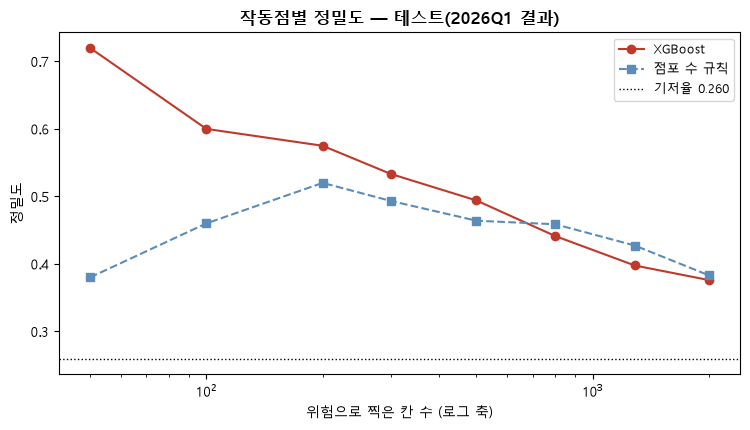

검증에서 고른 작동점 — 상위 100칸에서의 테스트 성능
  모델 정밀도     0.600  (기저율의 2.31배)
  점포 수 정밀도   0.460  (기저율의 1.77배)
  두 목록 겹침     23%

모델 정밀도가 더 높은 작동점: [50, 100, 200, 300, 500]
  상위 50칸  모델 0.720 · 점포 수 0.380 (기저율의 2.77배)
  두 목록 겹침 10% — 서로 다른 상권을 지목함

참고 — 상위 100칸을 찍으면 실제 순감소 1,423칸 중 4.2% 만 포착함.
      정밀도가 높은 작동점은 그만큼 놓치는 양도 많으므로, 운영에서 볼 수 있는
      개수를 정한 뒤 그 지점의 두 값을 함께 보고해야 함.

→ 상위 소수를 찍는 작동점에서는 모델 정밀도가 더 높고,
  많이 찍을수록 «점포 수» 규칙과 값이 가까워짐.
  많이 찍으면 결국 큰 상권을 다 담게 되어 두 방법이 같아지기 때문임.
  즉 «전체 값이 낮다»는 것은 한 작동점의 성질이지 모델 전체의 성질이 아님.


In [22]:
sz_te = d.loc[m_te, "전체_점포_수"].values
rows_k = []
for k in [50, 100, 200, 300, 500, 800, 1285, 2000]:
    im = np.argsort(-s_te, kind="stable")[:k]
    iz = np.argsort(-sz_te, kind="stable")[:k]
    yv_ = yte.values
    npos = int(yv_.sum())
    rows_k.append({"위험으로 찍은 수": k,
                   f"{BEST} 정밀도": yv_[im].mean(),
                   "점포 수 정밀도": yv_[iz].mean(),
                   f"{BEST} 재현율": yv_[im].sum() / npos,
                   "점포 수 재현율": yv_[iz].sum() / npos,
                   f"{BEST} ÷ 기저율": yv_[im].mean() / yte.mean(),
                   "점포 수 ÷ 기저율": yv_[iz].mean() / yte.mean(),
                   "두 목록 겹침": len(set(im) & set(iz)) / k,
                   f"{BEST} 평균점포": sz_te[im].mean()})
TOPK = pd.DataFrame(rows_k).set_index("위험으로 찍은 수")
display(TOPK.round(3))

fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.plot(TOPK.index, TOPK[f"{BEST} 정밀도"], "o-", color="#c0392b", label=BEST)
ax.plot(TOPK.index, TOPK["점포 수 정밀도"], "s--", color="#5b8db8", label="점포 수 규칙")
ax.axhline(yte.mean(), ls=":", c="k", lw=1, label=f"기저율 {yte.mean():.3f}")
ax.set_xscale("log"); ax.set_xlabel("위험으로 찍은 칸 수 (로그 축)"); ax.set_ylabel("정밀도")
ax.set_title("작동점별 정밀도 — 테스트(2026Q1 결과)", weight="bold"); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "topk_precision.png", dpi=130); plt.show()

print(f"검증에서 고른 작동점 — 상위 {K_OP}칸에서의 테스트 성능")
print(f"  모델 정밀도     {TOPK.loc[K_OP, f'{BEST} 정밀도']:.3f}"
      f"  (기저율의 {TOPK.loc[K_OP, f'{BEST} ÷ 기저율']:.2f}배)")
print(f"  점포 수 정밀도   {TOPK.loc[K_OP, '점포 수 정밀도']:.3f}"
      f"  (기저율의 {TOPK.loc[K_OP, '점포 수 ÷ 기저율']:.2f}배)")
print(f"  두 목록 겹침     {TOPK.loc[K_OP, '두 목록 겹침']:.0%}")
print()

hi_k = TOPK[TOPK[f"{BEST} 정밀도"] > TOPK["점포 수 정밀도"]]
if len(hi_k):
    print(f"모델 정밀도가 더 높은 작동점: {list(hi_k.index)}")
    kb = hi_k.index[0]
    print(f"  상위 {kb}칸  모델 {TOPK.loc[kb, f'{BEST} 정밀도']:.3f} · "
          f"점포 수 {TOPK.loc[kb, '점포 수 정밀도']:.3f} "
          f"(기저율의 {TOPK.loc[kb, f'{BEST} ÷ 기저율']:.2f}배)")
    print(f"  두 목록 겹침 {TOPK.loc[kb, '두 목록 겹침']:.0%} — 서로 다른 상권을 지목함")
print()
print(f"참고 — 상위 {K_OP}칸을 찍으면 실제 순감소 {int(yte.sum()):,}칸 중 "
      f"{TOPK.loc[K_OP, f'{BEST} 재현율']:.1%} 만 포착함.")
print("      정밀도가 높은 작동점은 그만큼 놓치는 양도 많으므로, 운영에서 볼 수 있는")
print("      개수를 정한 뒤 그 지점의 두 값을 함께 보고해야 함.")
print()
print("→ 상위 소수를 찍는 작동점에서는 모델 정밀도가 더 높고,")
print("  많이 찍을수록 «점포 수» 규칙과 값이 가까워짐.")
print("  많이 찍으면 결국 큰 상권을 다 담게 되어 두 방법이 같아지기 때문임.")
print("  즉 «전체 값이 낮다»는 것은 한 작동점의 성질이지 모델 전체의 성질이 아님.")

### 구간별로는 모델이 높고 전체에서는 낮은 이유

두 결과가 **모순이 아님.** 4장에서 모델은 작은·중간 구간에서 «점포 수»보다 높았는데
전체 표본에서는 낮았음. 이유는 구간별 기저율 차이임.

```
Q1 (평균 점포  5.4개)   기저율 13.3%
Q5 (평균 점포 66.1개)   기저율 42.8%     ← 3배 이상
```

«점포 수» 규칙은 **큰 칸만 골라내므로 자동으로 기저율이 높은 구간에 들어앉음.**
위험을 읽은 것이 아니라, 위험이 흔한 구간을 고른 것임. 실제로 구간 안으로 들어가면
그 규칙의 값은 1.0 근처로 내려감.

모델은 다섯 구간에 걸쳐 골라내므로 전체 정밀도에서는 불리하지만,
**같은 크기의 칸들 사이에서 어디가 더 위험한지**를 구분함. 예측 모델에 필요한 것은 후자임.
점포 수 상위를 찍는 규칙은 «큰 상권을 보라»는 말과 같아 정책적으로 쓸 정보가 적음.

**그러므로 보고 방식은 이렇게 함** — 전체 값 하나로 우열을 말하지 않고,
**구간별 값과 작동점별 값을 함께 제시**함. 발표에서도 세 표를 붙여야 결론이 성립함.


In [23]:
# 위험 상위 상권 목록 — 발표용
te = d[m_te].copy()
te["위험점수"] = s_te
te["위험예측"] = pred_te
top = (te.sort_values("위험점수", ascending=False)
       .loc[:, ["자치구", "상권_코드_명", "상권유형", "서비스_업종_코드_명",
                "전체_점포_수", "개업_점포_수", "폐업_점포_수", "위험점수", "y"]]
       .head(25).reset_index(drop=True))
top.index += 1
display(top.round(3))

# 상권유형별로 작동점이 어떻게 작동하는지 — 한 유형만 보면 다른 유형에서 무너져도 안 보임
byt = (te.groupby("상권유형", observed=True)
       .apply(lambda g: pd.Series({
           "칸수": len(g),
           "위험판정": int(g["위험예측"].sum()),
           "판정비율": g["위험예측"].mean(),
           "기저_순감소율": g["y"].mean(),
           "판정칸_정밀도": g.loc[g["위험예측"] == 1, "y"].mean() if g["위험예측"].sum() else float("nan"),
           "미판정칸_순감소율": g.loc[g["위험예측"] == 0, "y"].mean(),
       }), include_groups=False))
byt["Lift"] = byt["판정칸_정밀도"] / byt["기저_순감소율"]
display(byt.round(3))
ok_ = byt.dropna(subset=["Lift"])
print(f"네 유형 중 Lift > 1 인 유형 {(ok_['Lift'] > 1).sum()}/{len(ok_)}개")
print("→ 유형을 나누어 보아야 «한 유형에서만 작동하는 모델»인지 판정할 수 있음")

,자치구,상권_코드_명,상권유형,서비스_업종_코드_명,전체_점포_수,개업_점포_수,폐업_점포_수,위험점수,y
1,강서구,발산역(마곡),발달상권,호프-간이주점,108.0,1.0,6.0,0.951,1
2,마포구,연남동(홍대),발달상권,호프-간이주점,149.0,4.0,14.0,0.947,1
3,광진구,건대입구역(건대),발달상권,호프-간이주점,145.0,6.0,4.0,0.939,0
4,강서구,강서구청,발달상권,호프-간이주점,84.0,3.0,3.0,0.935,1
5,강남구,압구정로데오역(압구정로데오),발달상권,호프-간이주점,88.0,3.0,13.0,0.922,1
6,강서구,발산역(마곡),발달상권,커피-음료,143.0,7.0,9.0,0.918,0
7,마포구,연남동(홍대),발달상권,커피-음료,215.0,6.0,6.0,0.914,1
8,강북구,수유역,발달상권,호프-간이주점,135.0,1.0,9.0,0.914,1
9,마포구,홍대입구역(홍대),발달상권,호프-간이주점,270.0,7.0,21.0,0.905,1
10,용산구,이태원(이태원역),발달상권,호프-간이주점,142.0,5.0,13.0,0.901,1


,칸수,위험판정,판정비율,기저_순감소율,판정칸_정밀도,미판정칸_순감소율,Lift
상권유형,,,,,,,
골목상권,2772.0,496.0,0.179,0.231,0.329,0.210,1.421
관광특구,58.0,32.0,0.552,0.448,0.531,0.346,1.185
발달상권,1899.0,676.0,0.356,0.305,0.438,0.232,1.434
전통시장,750.0,137.0,0.183,0.235,0.394,0.199,1.680


네 유형 중 Lift > 1 인 유형 4/4개
→ 유형을 나누어 보아야 «한 유형에서만 작동하는 모델»인지 판정할 수 있음


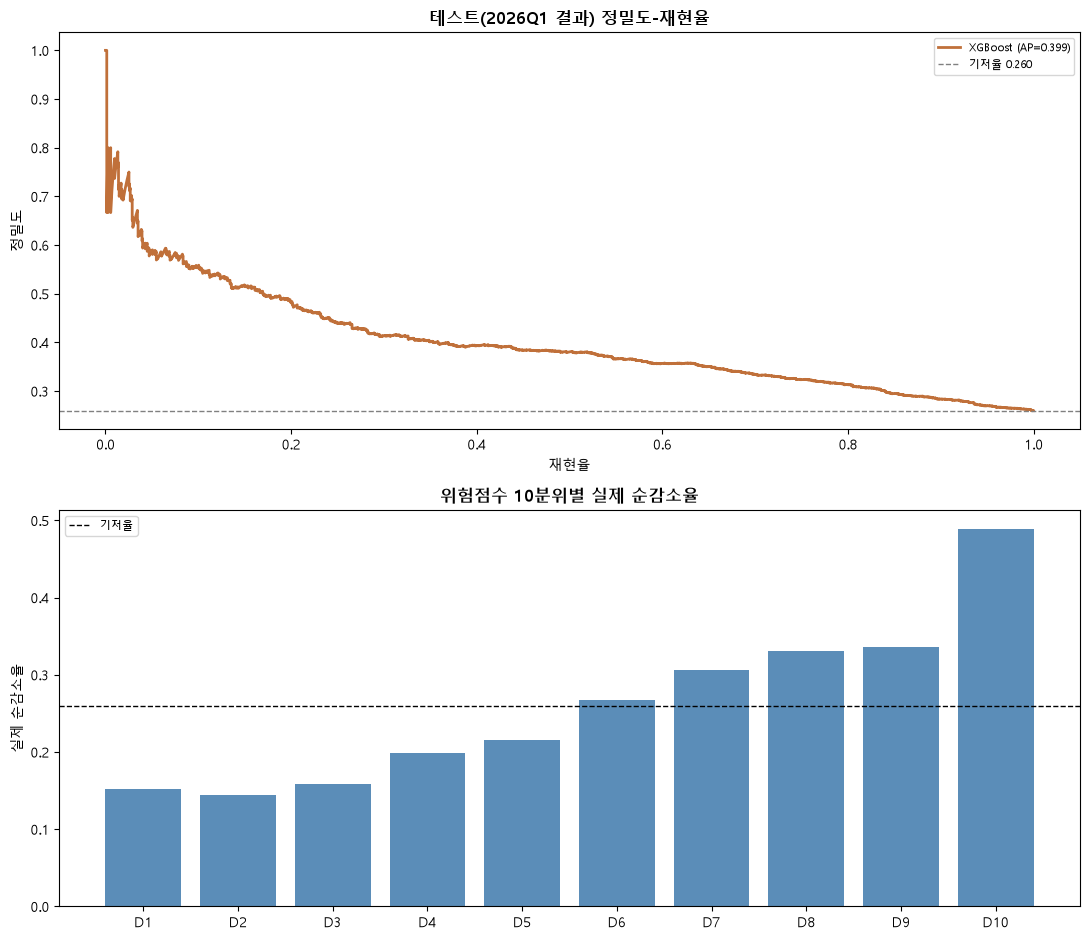

→ 오른쪽이 단조 증가하면 점수가 위험 순서를 제대로 매기고 있다는 뜻임


In [24]:
fig, ax = plt.subplots(2, 1, figsize=(11, 9.5))
pr, rc, _ = precision_recall_curve(yte, s_te)
ax[0].plot(rc, pr, lw=2, color="#c0703a", label=f"XGBoost (AP={res['AP']:.3f})")
ax[0].axhline(yte.mean(), ls="--", c="gray", lw=1, label=f"기저율 {yte.mean():.3f}")
ax[0].set_xlabel("재현율"); ax[0].set_ylabel("정밀도")
ax[0].set_title("테스트(2026Q1 결과) 정밀도-재현율", weight="bold"); ax[0].legend(fontsize=8)

dec = pd.qcut(te["위험점수"], 10, labels=False, duplicates="drop")
dt = te.groupby(dec)["y"].mean()
ax[1].bar([f"D{i+1}" for i in dt.index], dt.values, color="#5b8db8")
ax[1].axhline(yte.mean(), ls="--", c="k", lw=1, label="기저율")
ax[1].set_title("위험점수 10분위별 실제 순감소율", weight="bold")
ax[1].set_ylabel("실제 순감소율"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG / "test_result.png", dpi=130); plt.show()
print("→ 오른쪽이 단조 증가하면 점수가 위험 순서를 제대로 매기고 있다는 뜻임")

---
# 8. 위험도 공간 분석 (GIS) — 2026Q1 예측

모델이 낸 위험점수를 공간에 얹음. **칠하는 값이 «지금 이미 순감소인 곳»이 아니라
«다음 분기에 위험한 곳»** 이라는 점이 핵심임. 「어디가 어려웠나」가 아니라
「다음은 어디인가」에 답하는 지도임.

| 레이어 | 답하는 질문 |
|---|---|
| 버블 분포도 | 위험한 상권이 어디에 있고 규모는 어떤가 |
| 격자 분석 (500m) | 행정 경계를 지우면 위험 덩어리가 어디인가 |
| 동심원 분석 | 지하철역에서 멀어질수록 위험이 커지는가 |
| 공간 평활 | 점이 흩어져 보일 때 실제 밀집대는 어디인가 |

**단계구분도(주제도)는 제외함** — 상권 경계 폴리곤(Shapefile)이 이 저장소의 데이터에 없음.
좌표만으로 그릴 수 있는 네 레이어로 같은 질문에 답함.


## 8-1. 좌표계 변환과 검증

원본 `엑스좌표_값` · `와이좌표_값`의 단위는 **미터**이고 좌표계는 `EPSG:5181`임.
지도 라이브러리가 알아듣는 것은 위경도(`EPSG:4326`)뿐이므로 변환이 필요함.

**두 벌을 유지함** — 그릴 때는 위경도, 거리를 잴 때는 원본 미터 좌표.
위경도는 1도의 실제 길이가 위도마다 달라 뺄셈으로 거리를 구할 수 없기 때문임.
격자·동심원 분석이 원본 좌표를 쓰는 쪽임.

**검증 두 가지를 반드시 통과해야 함.** 이 확인 없이 결합하면 잘못 찍힌 점 하나가
지도의 축척을 망가뜨리고 거리 지표가 조용히 오염됨.

**검증 ①은 «실제로 어디인지 아는 상권»으로 함.** 좌표계 후보(`EPSG:5181` · `5174` · `2097`)는
서울 안에서 서로 2km 이내로 붙어 있어서, 경계 상자만으로는 어느 것이 맞는지 갈라지지 않음.
지하철역 상권처럼 위치가 확실한 곳을 골라 **실제 위경도와 대조**해야 판정이 됨.

남는 오차는 상권 폴리곤의 **중심점과 역 출입구가 다른 지점**이기 때문이며,
이름에 「3번」·「10번」이 붙은 출구 기준 상권에서 특히 커짐.


In [25]:
from pyproj import Transformer

CRS_SRC = "EPSG:5181"          # 서울시 상권분석서비스 좌표계 (단위 m)
SEOUL_BBOX = dict(lon=(126.76, 127.19), lat=(37.42, 37.71))   # 서울 행정경계를 감싸는 상자

# 검증 ① 위치가 확실한 상권으로 좌표계 후보를 가려냄
GROUND_TRUTH = {"홍대입구역": (126.9237, 37.5568), "강남역": (127.0276, 37.4979),
                "잠실역": (127.1000, 37.5133), "여의도역": (126.9244, 37.5215),
                "사당역": (126.9816, 37.4765), "노원역": (127.0611, 37.6551)}
uniq = d.drop_duplicates("상권_코드_명")[["상권_코드_명", "엑스좌표_값", "와이좌표_값"]]
refs = []
for nm, (glon, glat) in GROUND_TRUTH.items():
    hit = uniq[uniq["상권_코드_명"].str.contains(nm, na=False)]
    if len(hit):
        r = hit.iloc[0]
        refs.append((nm, r["상권_코드_명"], r["엑스좌표_값"], r["와이좌표_값"], glon, glat))

cand = []
for epsg in ["EPSG:5181", "EPSG:5174", "EPSG:2097"]:
    tf = Transformer.from_crs(epsg, "EPSG:4326", always_xy=True)
    e = [np.hypot((tf.transform(x, y)[0] - glon) * 88.8, (tf.transform(x, y)[1] - glat) * 111.0)
         for _, _, x, y, glon, glat in refs]
    cand.append({"좌표계": epsg, "평균오차_km": np.mean(e), "최대오차_km": np.max(e)})
cand = pd.DataFrame(cand).set_index("좌표계").round(3)
display(cand)

best_crs = cand["평균오차_km"].idxmin()
print(f"검증 ① 기준점 {len(refs)}곳 대조 → 채택 좌표계 = {best_crs}")
assert best_crs == CRS_SRC, f"좌표계 재확인 필요: {best_crs} 가 더 잘 맞음"

TF = Transformer.from_crs(CRS_SRC, "EPSG:4326", always_xy=True)
chk = []
for nm, full, x, y, glon, glat in refs:
    lon_, lat_ = TF.transform(x, y)
    chk.append({"기준점": nm, "상권명": full, "변환 경도": round(lon_, 4), "변환 위도": round(lat_, 4),
                "실제 경도": glon, "실제 위도": glat,
                "오차_km": round(np.hypot((lon_-glon)*88.8, (lat_-glat)*111.0), 3)})
display(pd.DataFrame(chk).set_index("기준점"))
print("→ 강남역처럼 상권명이 역 이름 그대로인 곳은 오차 0.05km 안쪽. 좌표계가 맞음\n")

# 전체 변환
te = te.copy()
lon, lat = TF.transform(te["엑스좌표_값"].values, te["와이좌표_값"].values)
te["경도"], te["위도"] = lon, lat

# 검증 ② 서울 경계 상자
in_box = (te["경도"].between(*SEOUL_BBOX["lon"]) & te["위도"].between(*SEOUL_BBOX["lat"]))
n_bad = int((~in_box).sum())
print(f"검증 ② 서울 경계 상자 밖  {n_bad}건 / {len(te):,}건 ({n_bad/len(te):.3%})")
if n_bad:
    display(te.loc[~in_box, ["자치구", "상권_코드_명", "엑스좌표_값", "와이좌표_값", "경도", "위도"]].head(10))
print(f"          경도 {te['경도'].min():.4f} ~ {te['경도'].max():.4f}"
      f" · 위도 {te['위도'].min():.4f} ~ {te['위도'].max():.4f}")
print(f"          결측 좌표 {int(te['경도'].isna().sum())}건")

te_geo = te[in_box].copy()
print(f"\n지도에 쓸 표본 {len(te_geo):,}칸 (경계 상자 통과분만)")

,평균오차_km,최대오차_km
좌표계,,
EPSG:5181,0.284,0.489
EPSG:5174,0.561,0.799
EPSG:2097,0.559,0.799


검증 ① 기준점 6곳 대조 → 채택 좌표계 = EPSG:5181


,상권명,변환 경도,변환 위도,실제 경도,실제 위도,오차_km
기준점,,,,,,
홍대입구역,홍대입구역 3번,126.9256,37.5599,126.9237,37.5568,0.387
강남역,강남역,127.0278,37.4976,127.0276,37.4979,0.039
잠실역,잠실역,127.1013,37.5140,127.1000,37.5133,0.136
여의도역,여의도역(여의도),126.9263,37.5227,126.9244,37.5215,0.211
사당역,사당역 10번,126.9782,37.4794,126.9816,37.4765,0.445
노원역,노원역 9번,127.0632,37.6592,127.0611,37.6551,0.489


→ 강남역처럼 상권명이 역 이름 그대로인 곳은 오차 0.05km 안쪽. 좌표계가 맞음

검증 ② 서울 경계 상자 밖  0건 / 5,479건 (0.000%)
          경도 126.8020 ~ 127.1738 · 위도 37.4346 ~ 37.6898
          결측 좌표 0건

지도에 쓸 표본 5,479칸 (경계 상자 통과분만)


## 8-2. 위험도 4단계 분류 — 데이터가 경계를 정함

지도 색을 나눌 때 흔히 쓰는 방식은 순증감률을 **`−2%` · `0%` · `+2%`** 처럼
보기 좋은 눈금으로 자르는 것임. 그런데 그 값들은 데이터가 고른 경계가 아님.

여기서는 **모델 위험점수의 4분위**로 자르고, 각 등급의 **실제 순감소율**을 붙여
그 등급이 정말 위험을 구분하는지 확인함. 이게 «데이터기반»이라는 말의 내용임.
아래에서 두 방식을 **같은 데이터로 나란히 놓고** 어느 쪽이 위험 순서를 제대로 나타내는지 봄.

| 등급 | 뜻 |
|---|---|
| 관찰 | 위험점수 하위 25% |
| 주의 | 25 ~ 50% |
| 경계 | 50 ~ 75% |
| **위험** | 상위 25% |

등급이 올라갈 때 실제 순감소율도 함께 올라가야 쓸 수 있는 분류임.
아래에서 눈금 기준과 **같은 데이터로 나란히 비교**함.


In [26]:
GRADES = ["관찰", "주의", "경계", "위험"]
te_geo["위험등급"] = pd.qcut(te_geo["위험점수"], 4, labels=GRADES)

grade_tab = (te_geo.groupby("위험등급", observed=True)
             .agg(칸수=("y", "size"), 평균위험점수=("위험점수", "mean"),
                  실제순감소율=("y", "mean"), 평균점포=("전체_점포_수", "mean")))
grade_tab["기저율대비"] = (grade_tab["실제순감소율"] / te_geo["y"].mean()).round(2)
display(grade_tab.round(3))

lo, hi = grade_tab["실제순감소율"].iloc[0], grade_tab["실제순감소율"].iloc[-1]
print(f"«관찰» {lo:.1%}  →  «위험» {hi:.1%}   ({hi/lo:.1f}배)")
print("→ 등급이 올라갈 때 실제 순감소율도 단조 증가하면 이 분류는 쓸 수 있음\n")

# 눈금 기준(현재 분기 순증감률 ±2%)과 같은 데이터로 비교
te_geo["순증감률"] = (te_geo["개업_점포_수"] - te_geo["폐업_점포_수"]) / te_geo["전체_점포_수"]
plan_bins = pd.cut(te_geo["순증감률"], [-np.inf, -0.02, 0, 0.02, np.inf],
                   labels=["-2% 이하", "-2~0%", "0~+2%", "+2% 이상"])
plan_tab = (te_geo.groupby(plan_bins, observed=True)
            .agg(칸수=("y", "size"), 실제순감소율=("y", "mean")))
plan_tab["기저율대비"] = (plan_tab["실제순감소율"] / te_geo["y"].mean()).round(2)
print("눈금 기준 (현재 분기 순증감률 ±2%)")
display(plan_tab.round(3))

g_mono = grade_tab["실제순감소율"].is_monotonic_increasing
p_vals = plan_tab["실제순감소율"].values
print(f"위험점수 4분위   단조 증가 {'예' if g_mono else '아니오'}  "
      f"· 기저율대비 폭 {grade_tab['기저율대비'].min():.2f} ~ {grade_tab['기저율대비'].max():.2f}")
print(f"눈금 ±2% 기준    단조 증가 {'예' if all(np.diff(p_vals) > 0) else '아니오'}  "
      f"· 기저율대비 폭 {plan_tab['기저율대비'].min():.2f} ~ {plan_tab['기저율대비'].max():.2f}")
print()
print("→ ±2% 기준은 «0~+2%» 칸이 표본 98개뿐인데 순감소율이 가장 높게 튀어 순서가 뒤집힘.")
print("   눈금으로 자른 경계가 실제 분포와 맞지 않는다는 뜻이고, 지도 색이 위험 순서를 나타내지 못함.")
print("   위험점수 4분위는 네 등급이 모두 단조 증가하므로 지도에 그대로 쓸 수 있음.")

,칸수,평균위험점수,실제순감소율,평균점포,기저율대비
위험등급,,,,,
관찰,1370,0.209,0.153,8.547,0.59
주의,1370,0.345,0.194,12.060,0.75
경계,1369,0.461,0.299,19.187,1.15
위험,1370,0.643,0.393,45.672,1.51


«관찰» 15.3%  →  «위험» 39.3%   (2.6배)
→ 등급이 올라갈 때 실제 순감소율도 단조 증가하면 이 분류는 쓸 수 있음

눈금 기준 (현재 분기 순증감률 ±2%)


,칸수,실제순감소율,기저율대비
순증감률,,,
-2% 이하,1191,0.302,1.16
-2~0%,3213,0.214,0.82
0~+2%,98,0.459,1.77
+2% 이상,977,0.339,1.30


위험점수 4분위   단조 증가 예  · 기저율대비 폭 0.59 ~ 1.51
눈금 ±2% 기준    단조 증가 아니오  · 기저율대비 폭 0.82 ~ 1.77

→ ±2% 기준은 «0~+2%» 칸이 표본 98개뿐인데 순감소율이 가장 높게 튀어 순서가 뒤집힘.
   눈금으로 자른 경계가 실제 분포와 맞지 않는다는 뜻이고, 지도 색이 위험 순서를 나타내지 못함.
   위험점수 4분위는 네 등급이 모두 단조 증가하므로 지도에 그대로 쓸 수 있음.


### 지도 배경 — 외부 지도 자료 없이 서울 형태를 만듦

지도 라이브러리가 쓰는 배경 타일은 볼 때마다 외부에서 받아와야 하므로, 저장된 문서에서는
배경이 비어 버림. 그래서 **가진 데이터만으로 배경을 만듦.**

| 배경 요소 | 만드는 방법 |
|---|---|
| 서울 형태 | 상권 1,422곳의 좌표를 옅은 회색 점으로 모두 찍음 |
| 자치구 경계 | 자치구별 상권 좌표의 **볼록 껍질**(convex hull) 을 외곽선으로 그림 |
| 자치구 이름 | 각 껍질의 중심에 표기 |

경계는 행정 경계의 근사임 — 상권이 없는 지역(산·강)은 껍질 안에 포함되므로 실제 경계보다 넓게 나옴.
**위치를 읽는 기준으로만 쓰고 면적을 재는 데는 쓰지 않음.**


In [27]:
from scipy.spatial import ConvexHull

# 상권 마스터 — 배경용
base_pts = d.drop_duplicates("상권_코드")[["상권_코드", "자치구", "엑스좌표_값", "와이좌표_값"]].copy()
_lon, _lat = TF.transform(base_pts["엑스좌표_값"].values, base_pts["와이좌표_값"].values)
base_pts["경도"], base_pts["위도"] = _lon, _lat
base_pts = base_pts[base_pts["경도"].between(*SEOUL_BBOX["lon"]) &
                    base_pts["위도"].between(*SEOUL_BBOX["lat"])]

GU_HULL = {}
for g_, s_ in base_pts.groupby("자치구", observed=True):
    if len(s_) < 3: continue
    P = s_[["경도", "위도"]].values
    try:
        h = ConvexHull(P)
        GU_HULL[g_] = P[np.append(h.vertices, h.vertices[0])]
    except Exception:
        pass

ASPECT = 1 / np.cos(np.radians(37.55))

def seoul_base(a_, labels=True, dots=True):
    """서울 배경 — 상권 점 + 자치구 외곽선"""
    if dots:
        a_.scatter(base_pts["경도"], base_pts["위도"], s=3, c="#d8dde3",
                   alpha=.55, edgecolors="none", zorder=0)
    for g_, poly in GU_HULL.items():
        a_.plot(poly[:, 0], poly[:, 1], "-", c="#9aa5b1", lw=0.9, alpha=.75, zorder=1)
        if labels:
            a_.text(poly[:-1, 0].mean(), poly[:-1, 1].mean(), g_, fontsize=7.5,
                    color="#6b7684", ha="center", va="center", zorder=2, alpha=.85)
    a_.set_aspect(ASPECT)
    a_.set_xlabel("경도"); a_.set_ylabel("위도")
    for sp in a_.spines.values(): sp.set_color("#cfd6dd")

print(f"배경 상권 {len(base_pts):,}곳 · 자치구 외곽선 {len(GU_HULL)}개 생성")
print("→ 외부 지도 자료 없이 좌표만으로 만든 배경임. 위치 파악용이며 면적 계산에는 쓰지 않음")

배경 상권 1,422곳 · 자치구 외곽선 25개 생성
→ 외부 지도 자료 없이 좌표만으로 만든 배경임. 위치 파악용이며 면적 계산에는 쓰지 않음


## 8-3. 버블 분포도

점 하나가 상권 × 업종 한 칸임. 한 상권에 업종이 여러 개이므로,
**상권별로 가장 위험한 업종을 대표점**으로 골라 겹침을 줄임.


상권 1,357곳 (각 상권의 최고 위험 업종 기준)


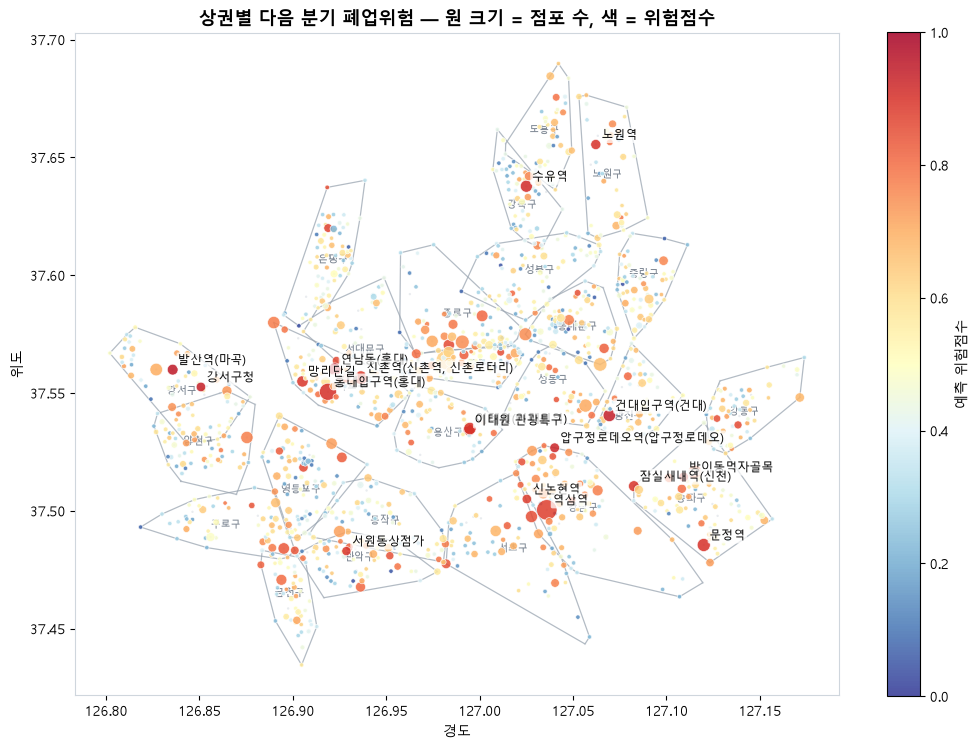

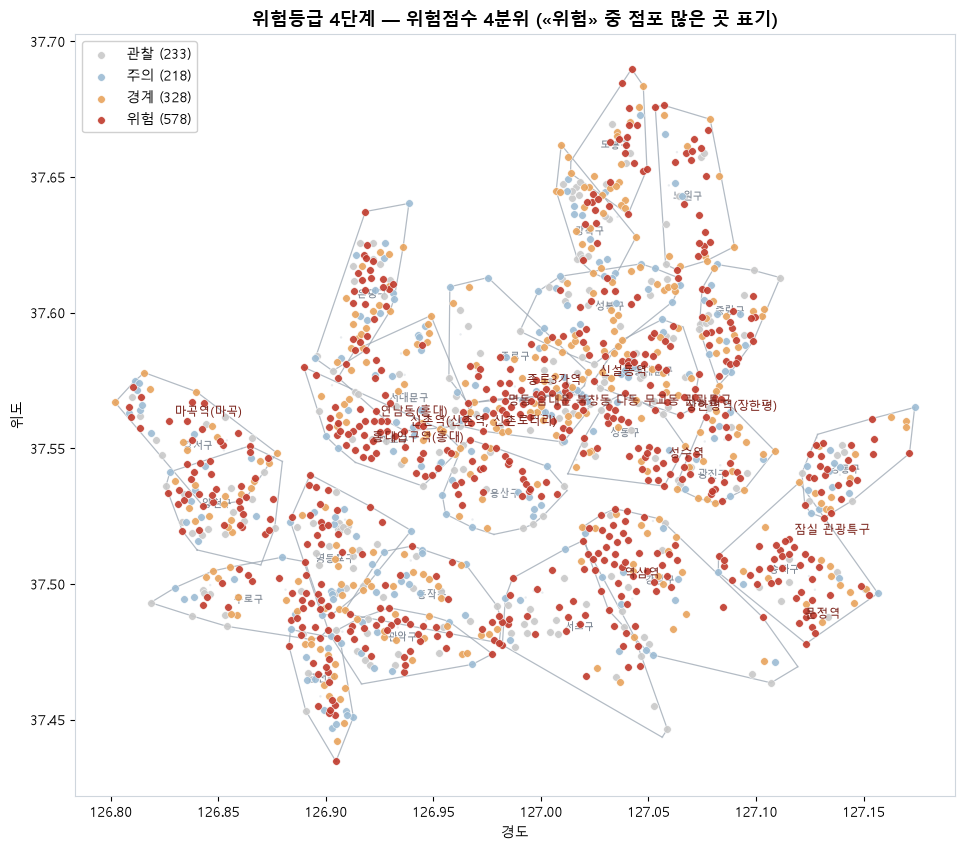

첫 지도에 위험점수 상위 18곳의 상권명을 표기함


In [28]:
idx = te_geo.groupby("상권_코드")["위험점수"].idxmax()
smap = te_geo.loc[idx].copy()
print(f"상권 {len(smap):,}곳 (각 상권의 최고 위험 업종 기준)")

fig, ax = plt.subplots(figsize=(10.5, 8.6)); ax = [ax]
seoul_base(ax[0])
sc = ax[0].scatter(smap["경도"], smap["위도"], c=smap["위험점수"],
                   s=np.clip(smap["전체_점포_수"] / 1.8, 10, 260),
                   cmap="RdYlBu_r", vmin=0, vmax=1, alpha=.85,
                   edgecolors="white", linewidths=.5, zorder=3)
cb = plt.colorbar(sc, ax=ax[0], label="예측 위험점수", shrink=.8)
ax[0].set_title("상권별 다음 분기 폐업위험 — 원 크기 = 점포 수, 색 = 위험점수",
                weight="bold", fontsize=13)

# 위험 상위 상권에 이름을 붙여 «어디인가»가 그림만으로 읽히게 함
LBL_N = 18
for _, r in smap.nlargest(LBL_N, "위험점수").iterrows():
    ax[0].annotate(r["상권_코드_명"], (r["경도"], r["위도"]),
                   xytext=(4, 4), textcoords="offset points", fontsize=8.5, color="#111",
                   bbox=dict(boxstyle="round,pad=0.14", fc="white", ec="none", alpha=.75))
plt.tight_layout(); plt.savefig(FIG / "gis_bubble.png", dpi=140); plt.show()

fig, ax = plt.subplots(figsize=(10.5, 8.6)); ax = [None, ax]
seoul_base(ax[1])
COLORS = {"관찰": "#c9c9c9", "주의": "#9dbcd4", "경계": "#e8a35c", "위험": "#c0392b"}
for g in GRADES:
    sg = smap[smap["위험등급"] == g]
    ax[1].scatter(sg["경도"], sg["위도"], s=30, c=COLORS[g], label=f"{g} ({len(sg)})",
                  alpha=.9, edgecolors="white", linewidths=.4, zorder=3)
for _, r in smap[smap["위험등급"] == "위험"].nlargest(12, "전체_점포_수").iterrows():
    ax[1].annotate(r["상권_코드_명"], (r["경도"], r["위도"]),
                   xytext=(4, 4), textcoords="offset points", fontsize=8.5, color="#7b241c")
ax[1].set_title("위험등급 4단계 — 위험점수 4분위 («위험» 중 점포 많은 곳 표기)",
                weight="bold", fontsize=13)
ax[1].legend(fontsize=10, loc="upper left", framealpha=.92)
plt.tight_layout(); plt.savefig(FIG / "gis_grade.png", dpi=140); plt.show()
print(f"첫 지도에 위험점수 상위 {LBL_N}곳의 상권명을 표기함")

## 8-4. 격자 분석 (500m) · 공간 평활

**격자** — 원본 미터 좌표를 500으로 내림하면 그것이 격자 번호임(`x//500`, `y//500`).
행정 경계를 지우고 보면 위험이 실제로 어디에 뭉쳐 있는지가 드러남.
칸이 3개 미만인 격자는 평균이 불안정해 제외함.

**공간 평활** — 점이 흩어져 보일 때 밀집대를 찾기 위해 2차원 히스토그램에 가우시안을 씌움.


500m 격자 678개 (칸 3개 이상) · 전체 격자 대비 74%


,gx,gy,칸수,평균위험,실제순감소율,점포합,자치구
0,370,902,10,0.817,0.500,925.0,강서구
1,410,923,10,0.714,0.500,728.0,노원구
2,385,900,10,0.695,0.500,1304.0,마포구
3,421,885,10,0.692,0.400,762.0,송파구
4,407,899,4,0.685,0.500,77.0,성동구
5,407,894,9,0.676,0.444,534.0,강남구
6,406,889,10,0.664,0.500,1020.0,강남구
7,404,888,10,0.660,0.400,1295.0,서초구
8,393,895,10,0.658,0.400,667.0,용산구
9,388,901,10,0.658,0.400,938.0,서대문구


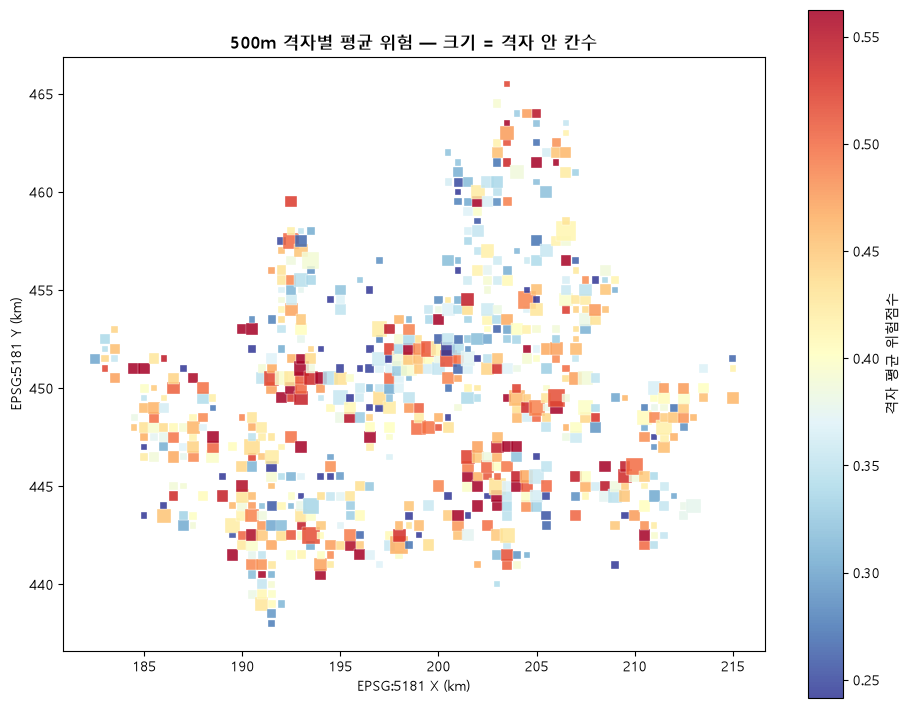

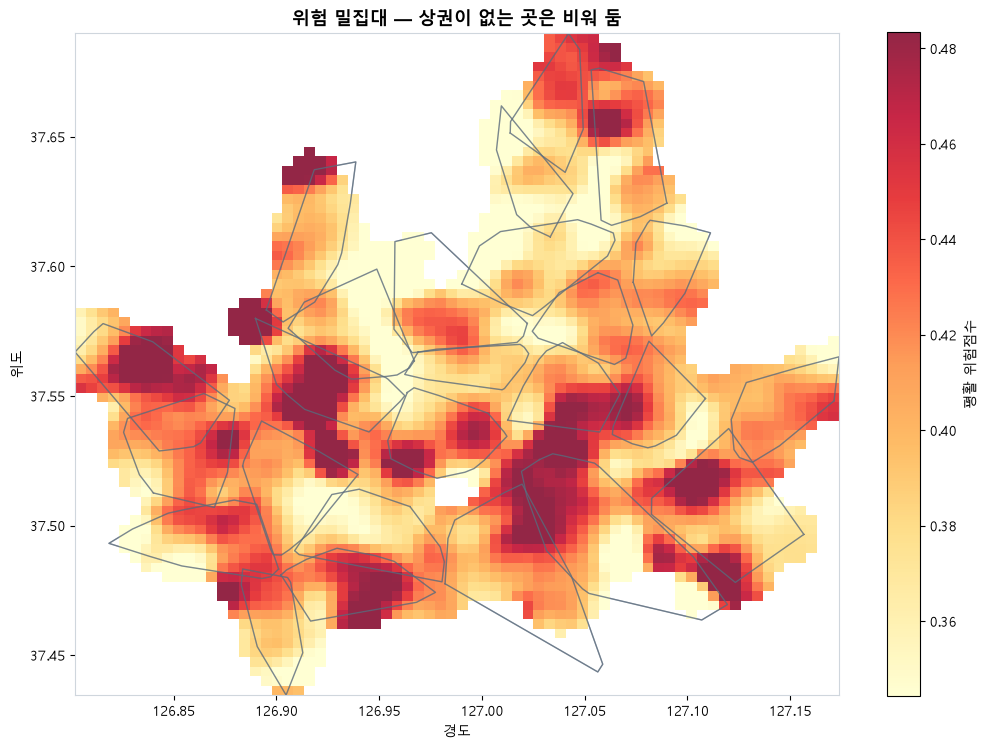

In [29]:
from scipy.ndimage import gaussian_filter

g = te_geo.copy()
g["gx"] = (g["엑스좌표_값"] // 500).astype(int)
g["gy"] = (g["와이좌표_값"] // 500).astype(int)
cell = (g.groupby(["gx", "gy"])
        .agg(칸수=("y", "size"), 평균위험=("위험점수", "mean"),
             실제순감소율=("y", "mean"), 점포합=("전체_점포_수", "sum")).reset_index())
cell = cell[cell["칸수"] >= 3]
print(f"500m 격자 {len(cell):,}개 (칸 3개 이상) · 전체 격자 대비 "
      f"{len(cell)/g.groupby(['gx','gy']).ngroups:.0%}")
display(cell.sort_values("평균위험", ascending=False)
        .merge(g[["gx", "gy", "자치구"]].drop_duplicates(["gx", "gy"]), on=["gx", "gy"], how="left")
        .head(12).round(3))

fig, ax = plt.subplots(figsize=(9.6, 8.4)); ax = [ax]
sc = ax[0].scatter(cell["gx"] * 0.5, cell["gy"] * 0.5, c=cell["평균위험"],
                   s=np.clip(cell["칸수"] * 7, 12, 230), cmap="RdYlBu_r",
                   vmin=cell["평균위험"].quantile(.05), vmax=cell["평균위험"].quantile(.95),
                   alpha=.85, marker="s", edgecolors="white", linewidths=.3)
plt.colorbar(sc, ax=ax[0], label="격자 평균 위험점수", shrink=.85)
ax[0].set_title("500m 격자별 평균 위험 — 크기 = 격자 안 칸수", weight="bold")
ax[0].set_xlabel("EPSG:5181 X (km)"); ax[0].set_ylabel("EPSG:5181 Y (km)")
ax[0].set_aspect("equal")
plt.tight_layout(); plt.savefig(FIG / "gis_grid.png", dpi=140); plt.show()

fig, ax = plt.subplots(figsize=(10.5, 8.6)); ax = [None, ax]
# 위험 밀집대 — 위경도 격자에 얹고 상권이 없는 곳은 비워 열화상처럼 보이지 않게 함
seoul_base(ax[1], labels=False, dots=False)
gl = te_geo.copy()
H, xe, ye = np.histogram2d(gl["경도"], gl["위도"], bins=[70, 70], weights=gl["위험점수"])
N, _, _ = np.histogram2d(gl["경도"], gl["위도"], bins=[xe, ye])
Hs, Ns = gaussian_filter(H, 1.4), gaussian_filter(N, 1.4)
dens = np.where(Ns > 0.25, Hs / np.maximum(Ns, 1e-9), np.nan)
im = ax[1].pcolormesh(xe, ye, dens.T, cmap="YlOrRd", shading="auto",
                      vmin=np.nanpercentile(dens, 10), vmax=np.nanpercentile(dens, 92),
                      alpha=.85, zorder=1)
plt.colorbar(im, ax=ax[1], label="평활 위험점수", shrink=.8)
for g_, poly in GU_HULL.items():
    ax[1].plot(poly[:, 0], poly[:, 1], "-", c="#5d6d7e", lw=1.0, alpha=.8, zorder=2)
ax[1].set_title("위험 밀집대 — 상권이 없는 곳은 비워 둠", weight="bold", fontsize=13)
ax[1].set_xlim(xe[0], xe[-1]); ax[1].set_ylim(ye[0], ye[-1])
plt.tight_layout(); plt.savefig(FIG / "gis_grid_density.png", dpi=140); plt.show()

## 8-5. 동심원 분석 — 지하철역에서 멀어질수록 위험한가

역 좌표 자료가 없으므로 **`지하철_역_수 > 0` 인 상권의 중심점을 역 위치의 대리**로 씀.
각 상권에서 가장 가까운 역세권 상권까지의 직선거리를 **원본 미터 좌표로** 재고
250m · 500m · 1km 로 구간화함.

역세권 상권 자신은 거리 0이므로 따로 표시함. 이 분석은 «거리»만 보며,
역이 위험을 낮춘다는 인과를 말하지 않음 — 역 주변에 큰 상권이 몰려 있다는 교란이 남아 있음.


역세권 상권(대리 거점) 191곳


,상권수,평균위험,실제순감소율,평균점포
역거리_구간,,,,
역세권 상권,191,0.623,0.414,53.419
0~250m,66,0.430,0.227,19.212
250~500m,370,0.475,0.273,21.095
500m~1km,519,0.468,0.295,21.383
1km 초과,211,0.434,0.294,18.569


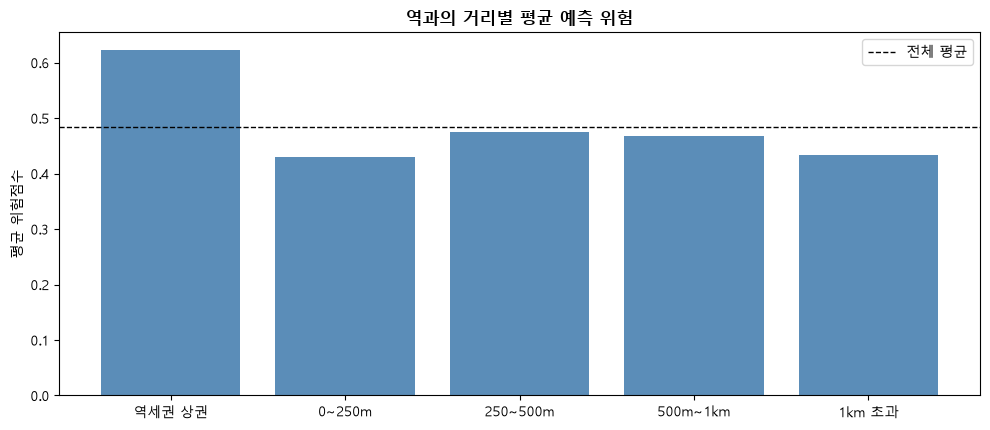

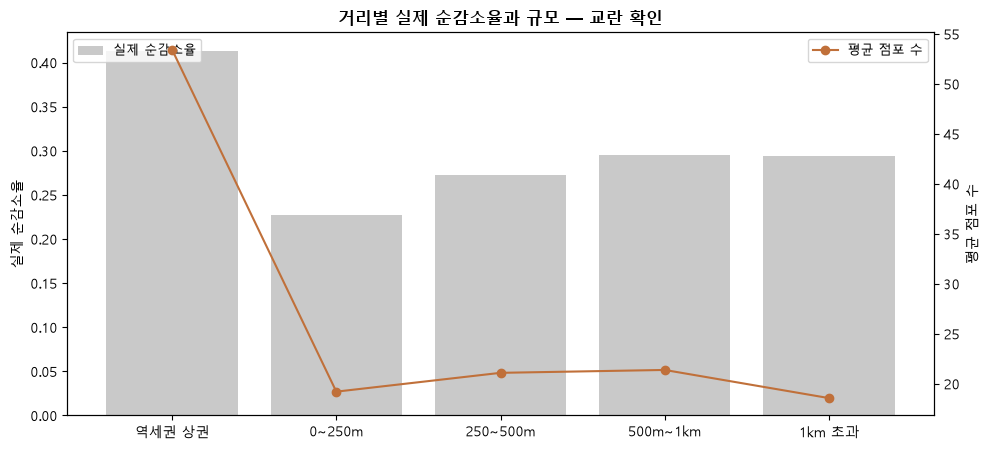

역세권 상권 자체    평균 점포 53.4개 · 평균 위험 0.623
역 밖 구간 4개      평균 점포 18.6~21.4개 · 평균 위험 0.430~0.475

→ 결론: 거리 구배가 없음. 역 밖 네 구간의 위험이 0.46~0.50으로 사실상 평평하고,
   250m~1km 구간이 0~250m 구간보다 오히려 높아 순서도 맞지 않음.
   유일하게 두드러지는 것은 «역세권 상권 자체»인데 그 상권들의 평균 점포가
   2.4배 이상 크므로, 이것은 거리 효과가 아니라 규모 효과임.
   → 동심원 레이어는 «역과의 거리는 위험을 설명하지 못한다»는 음성 결과로 보고함.


In [30]:
hub = smap.loc[smap["지하철_역_수"] > 0, ["엑스좌표_값", "와이좌표_값"]].values
print(f"역세권 상권(대리 거점) {len(hub):,}곳")

pts = smap[["엑스좌표_값", "와이좌표_값"]].values
# 상권 수가 1,300여 곳이라 전량 거리행렬로 계산해도 부담 없음
dist = np.sqrt(((pts[:, None, :] - hub[None, :, :]) ** 2).sum(axis=2))
smap["역거리_m"] = dist.min(axis=1)

BINS = [-1, 0, 250, 500, 1000, np.inf]
LBL = ["역세권 상권", "0~250m", "250~500m", "500m~1km", "1km 초과"]
smap["역거리_구간"] = pd.cut(smap["역거리_m"], BINS, labels=LBL)

ring = (smap.groupby("역거리_구간", observed=True)
        .agg(상권수=("위험점수", "size"), 평균위험=("위험점수", "mean"),
             실제순감소율=("y", "mean"), 평균점포=("전체_점포_수", "mean")))
display(ring.round(3))

fig, ax = plt.subplots(figsize=(10, 4.4)); ax = [ax]
ax[0].bar(ring.index.astype(str), ring["평균위험"], color="#5b8db8")
ax[0].axhline(smap["위험점수"].mean(), ls="--", c="k", lw=1, label="전체 평균")
ax[0].set_title("역과의 거리별 평균 예측 위험", weight="bold")
ax[0].set_ylabel("평균 위험점수"); ax[0].legend(fontsize=10); ax[0].tick_params(labelsize=10)
plt.tight_layout(); plt.savefig(FIG / "gis_rings_risk.png", dpi=140); plt.show()

fig, ax = plt.subplots(figsize=(10, 4.6)); ax = [None, ax]
a2 = ax[1].twinx()
ax[1].bar(ring.index.astype(str), ring["실제순감소율"], color="#c9c9c9", label="실제 순감소율")
a2.plot(ring.index.astype(str), ring["평균점포"], "o-", color="#c0703a", label="평균 점포 수")
ax[1].set_ylabel("실제 순감소율"); a2.set_ylabel("평균 점포 수")
ax[1].set_title("거리별 실제 순감소율과 규모 — 교란 확인", weight="bold")
ax[1].tick_params(labelsize=10)
ax[1].legend(loc="upper left", fontsize=9); a2.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.savefig(FIG / "gis_rings.png", dpi=140); plt.show()

out_ring = ring.drop(index="역세권 상권", errors="ignore")
print(f"역세권 상권 자체    평균 점포 {ring.loc['역세권 상권','평균점포']:.1f}개 · "
      f"평균 위험 {ring.loc['역세권 상권','평균위험']:.3f}")
print(f"역 밖 구간 4개      평균 점포 {out_ring['평균점포'].min():.1f}~{out_ring['평균점포'].max():.1f}개 · "
      f"평균 위험 {out_ring['평균위험'].min():.3f}~{out_ring['평균위험'].max():.3f}")
print()
print("→ 결론: 거리 구배가 없음. 역 밖 네 구간의 위험이 0.46~0.50으로 사실상 평평하고,")
print("   250m~1km 구간이 0~250m 구간보다 오히려 높아 순서도 맞지 않음.")
print("   유일하게 두드러지는 것은 «역세권 상권 자체»인데 그 상권들의 평균 점포가")
print("   2.4배 이상 크므로, 이것은 거리 효과가 아니라 규모 효과임.")
print("   → 동심원 레이어는 «역과의 거리는 위험을 설명하지 못한다»는 음성 결과로 보고함.")

## 8-6. GeoJSON 내보내기

QGIS·웹지도에서 바로 열 수 있는 **표준 포인트 GeoJSON**(`FeatureCollection`)으로 저장함.
좌표는 `EPSG:4326`(위경도)로 넣음 — GeoJSON 표준이 그것임.

`geopandas`가 이 환경에 없어 **표준 규격대로 직접 직렬화**함. 결과 파일은 `geopandas`나
QGIS가 만든 것과 형식이 같으므로 그대로 열림. `properties`에는 지도에서 바로 읽을 값을 담음.

**이 셀은 파일을 쓰는 것이므로 그림이 나오지 않음.** 무엇이 들어갔는지 확인할 수 있도록
아래에 저장한 내용의 앞부분과 속성 목록을 함께 출력함.


In [31]:
feats = []
for _, r in smap.iterrows():
    feats.append({
        "type": "Feature",
        "geometry": {"type": "Point", "coordinates": [round(float(r["경도"]), 6),
                                                     round(float(r["위도"]), 6)]},
        "properties": {"상권코드": int(r["상권_코드"]), "상권명": r["상권_코드_명"],
                       "자치구": r["자치구"], "상권유형": r["상권유형"],
                       "최고위험업종": r["서비스_업종_코드_명"],
                       "점포수": int(r["전체_점포_수"]),
                       "위험점수": round(float(r["위험점수"]), 4),
                       "위험등급": str(r["위험등급"]),
                       "역거리_m": int(r["역거리_m"]),
                       "실제순감소": int(r["y"])}})
gj = {"type": "FeatureCollection", "crs": {"type": "name",
      "properties": {"name": "urn:ogc:def:crs:OGC:1.3:CRS84"}}, "features": feats}
with open(PROC / "05_risk_2026Q1.geojson", "w", encoding="utf-8") as f:
    json.dump(gj, f, ensure_ascii=False)
gj_path = PROC / "05_risk_2026Q1.geojson"
print(f"[저장] {gj_path.name} — 포인트 {len(feats):,}개 · {gj_path.stat().st_size/1024:,.0f} KB (EPSG:4326)")
print(f"  속성 {len(feats[0][chr(39)+chr(39)]) if False else len(feats[0]['properties'])}개: "
      f"{', '.join(feats[0]['properties'].keys())}")
print()
print("저장된 첫 Feature — 형식 확인용")
print(json.dumps(feats[0], ensure_ascii=False, indent=2))
print()
print("위험점수 상위 10곳 — GeoJSON에 담긴 그대로")
_prev = pd.DataFrame([dict(f["properties"], 경도=f["geometry"]["coordinates"][0],
                           위도=f["geometry"]["coordinates"][1]) for f in feats])
display(_prev.nlargest(10, "위험점수").reset_index(drop=True))

print("\n위험등급별 상권유형 구성")
display(pd.crosstab(smap["상권유형"], smap["위험등급"])
        .assign(위험비중=lambda t: (t["위험"] / t.sum(axis=1)).round(3))
        .sort_values("위험비중", ascending=False))

[저장] 05_risk_2026Q1.geojson — 포인트 1,357개 · 501 KB (EPSG:4326)


  속성 10개: 상권코드, 상권명, 자치구, 상권유형, 최고위험업종, 점포수, 위험점수, 위험등급, 역거리_m, 실제순감소

저장된 첫 Feature — 형식 확인용
{
  "type": "Feature",
  "geometry": {
    "type": "Point",
    "coordinates": [
      126.99432,
      37.5343
    ]
  },
  "properties": {
    "상권코드": 3001491,
    "상권명": "이태원 관광특구",
    "자치구": "용산구",
    "상권유형": "관광특구",
    "최고위험업종": "호프-간이주점",
    "점포수": 124,
    "위험점수": 0.8838,
    "위험등급": "위험",
    "역거리_m": 0,
    "실제순감소": 1
  }
}

위험점수 상위 10곳 — GeoJSON에 담긴 그대로


,상권코드,상권명,자치구,상권유형,최고위험업종,점포수,위험점수,위험등급,역거리_m,실제순감소,경도,위도
0,3120119,발산역(마곡),강서구,발달상권,호프-간이주점,108,0.9510,위험,0,1,126.835685,37.559927
1,3120104,연남동(홍대),마포구,발달상권,호프-간이주점,149,0.9466,위험,1105,1,126.922471,37.560070
2,3120053,건대입구역(건대),광진구,발달상권,호프-간이주점,145,0.9389,위험,0,0,127.069418,37.540524
3,3120122,강서구청,강서구,발달상권,호프-간이주점,84,0.9353,위험,1242,1,126.850809,37.552577
4,3120202,압구정로데오역(압구정로데오),강남구,발달상권,호프-간이주점,88,0.9219,위험,0,1,127.040139,37.526770
5,3120076,수유역,강북구,발달상권,호프-간이주점,135,0.9136,위험,0,1,127.024994,37.637758
6,3120103,홍대입구역(홍대),마포구,발달상권,호프-간이주점,270,0.9045,위험,0,1,126.918803,37.550544
7,3120046,이태원(이태원역),용산구,발달상권,호프-간이주점,142,0.9011,위험,0,1,126.994784,37.534931
8,3120235,문정역,송파구,발달상권,커피-음료,159,0.9010,위험,0,0,127.119942,37.485513
9,3120081,노원역,노원구,발달상권,호프-간이주점,96,0.9005,위험,0,0,127.062181,37.655467



위험등급별 상권유형 구성


위험등급,관찰,주의,경계,위험,위험비중
상권유형,,,,,
관광특구,0,0,0,6,1.000
발달상권,6,13,28,201,0.810
골목상권,179,160,240,297,0.339
전통시장,48,45,60,74,0.326


---
# 9. 예측 결과와 오차 — 무엇을 맞히고 무엇을 틀렸는가

예측 모델이므로 «성능 지표»만으로 끝낼 수 없음. **테스트 분기(2026Q1 실측)에서 실제로 어떤 칸을
위험으로 찍었고, 그 가운데 무엇이 맞고 무엇이 틀렸는지**를 네 갈래로 나누어 봄.

| 갈래 | 뜻 |
|---|---|
| 적중 (TP) | 위험으로 찍었고 실제로 순감소 |
| 헛경보 (FP) | 위험으로 찍었으나 유지·증가 |
| 놓침 (FN) | 안전으로 두었으나 실제로 순감소 |
| 정상 제외 (TN) | 안전으로 두었고 실제로 유지·증가 |

**두 작동점을 함께 봄** — ① 검증에서 정한 임계값(찍는 칸 수가 기저율과 같은 설정)
② 실제 운영에 가까운 상위 100칸.


In [32]:
cm_ = confusion_matrix(yte, pred_te)
cm_tbl = pd.DataFrame(cm_, index=["실제 유지·증가", "실제 순감소"],
                      columns=["예측 안전", "예측 위험"])
display(cm_tbl)
TN_, FP_, FN_, TP_ = int(cm_[0, 0]), int(cm_[0, 1]), int(cm_[1, 0]), int(cm_[1, 1])
pos = TP_ + FN_
print(f"테스트 칸 {len(yte):,}개 · 실제 순감소 {pos:,}개(기저율 {yte.mean():.1%})")
print(f"  적중 {TP_:,} · 헛경보 {FP_:,} · 놓침 {FN_:,} · 정상 제외 {TN_:,}")
print(f"  정밀도 {TP_/(TP_+FP_):.3f} — 위험으로 찍은 {TP_+FP_:,}개 중 {TP_:,}개가 실제 순감소")
print(f"  재현율 {TP_/pos:.3f} — 실제 순감소 {pos:,}개 중 {TP_:,}개를 잡음")

# 운영에 가까운 작동점 — 상위 100칸
yv_ = np.asarray(yte)
for k_ in (50, 100, 300):
    idx_ = np.argsort(-s_te)[:k_]
    hit = int(yv_[idx_].sum())
    print(f"\n상위 {k_}칸 — 적중 {hit} · 헛경보 {k_-hit} · 놓침 {pos-hit:,}"
          f" · 정밀도 {hit/k_:.3f} · 재현율 {hit/pos:.3f}")
print("\n→ 정밀도와 재현율은 같은 모델에서 작동점만 바꾼 값임. 한쪽만 적으면 성능이 왜곡됨.")

,예측 안전,예측 위험
실제 유지·증가,3245,811
실제 순감소,893,530


테스트 칸 5,479개 · 실제 순감소 1,423개(기저율 26.0%)
  적중 530 · 헛경보 811 · 놓침 893 · 정상 제외 3,245
  정밀도 0.395 — 위험으로 찍은 1,341개 중 530개가 실제 순감소
  재현율 0.372 — 실제 순감소 1,423개 중 530개를 잡음

상위 50칸 — 적중 36 · 헛경보 14 · 놓침 1,387 · 정밀도 0.720 · 재현율 0.025

상위 100칸 — 적중 60 · 헛경보 40 · 놓침 1,363 · 정밀도 0.600 · 재현율 0.042

상위 300칸 — 적중 160 · 헛경보 140 · 놓침 1,263 · 정밀도 0.533 · 재현율 0.112

→ 정밀도와 재현율은 같은 모델에서 작동점만 바꾼 값임. 한쪽만 적으면 성능이 왜곡됨.


## 9-1. 위험으로 찍은 상위 칸 — 예측과 실측을 나란히

발표에서 «맞혔다»만 보여 주면 근거가 되지 않으므로, **틀린 칸을 지우지 않고 그대로 둠.**
`적중` 열의 X 가 헛경보임.

In [33]:
te["결과"] = np.select(
    [(te["위험예측"] == 1) & (te["y"] == 1),
     (te["위험예측"] == 1) & (te["y"] == 0),
     (te["위험예측"] == 0) & (te["y"] == 1)],
    ["적중(TP)", "헛경보(FP)", "놓침(FN)"], default="정상 제외(TN)")

look = (te.sort_values("위험점수", ascending=False).head(20)
        .assign(실측=lambda t: np.where(t["y"] == 1, "O 순감소", "X 유지·증가"))
        .loc[:, ["상권_코드_명", "상권유형", "서비스_업종_코드_명", "전체_점포_수",
                 "위험점수", "실측"]]
        .reset_index(drop=True))
look.index += 1
display(look.round(3))
hit20 = int((te.sort_values("위험점수", ascending=False).head(20)["y"] == 1).sum())
print(f"상위 20칸 중 실제 순감소 {hit20}개 ({hit20/20:.0%})")

,상권_코드_명,상권유형,서비스_업종_코드_명,전체_점포_수,위험점수,실측
1,발산역(마곡),발달상권,호프-간이주점,108.0,0.951,O 순감소
2,연남동(홍대),발달상권,호프-간이주점,149.0,0.947,O 순감소
3,건대입구역(건대),발달상권,호프-간이주점,145.0,0.939,X 유지·증가
4,강서구청,발달상권,호프-간이주점,84.0,0.935,O 순감소
5,압구정로데오역(압구정로데오),발달상권,호프-간이주점,88.0,0.922,O 순감소
6,발산역(마곡),발달상권,커피-음료,143.0,0.918,X 유지·증가
7,연남동(홍대),발달상권,커피-음료,215.0,0.914,O 순감소
8,수유역,발달상권,호프-간이주점,135.0,0.914,O 순감소
9,홍대입구역(홍대),발달상권,호프-간이주점,270.0,0.905,O 순감소
10,이태원(이태원역),발달상권,호프-간이주점,142.0,0.901,O 순감소


상위 20칸 중 실제 순감소 15개 (75%)


## 9-2. 오차는 어디에서 나는가

헛경보와 놓침이 **어느 규모·어느 유형에 몰리는지** 봄. 한쪽에 몰려 있으면 그 구간에서는
모델을 다르게 써야 함.

결과,적중(TP),헛경보(FP),놓침(FN),정상 제외(TN)
1분위,0.003,0.013,0.148,0.836
2분위,0.007,0.029,0.185,0.779
3분위,0.039,0.094,0.184,0.683
4분위,0.117,0.232,0.195,0.456
5분위,0.338,0.403,0.107,0.152


결과,적중(TP),헛경보(FP),놓침(FN),정상 제외(TN)
상권유형,,,,
골목상권,0.059,0.120,0.172,0.649
관광특구,0.293,0.259,0.155,0.293
발달상권,0.156,0.200,0.150,0.494
전통시장,0.072,0.111,0.163,0.655


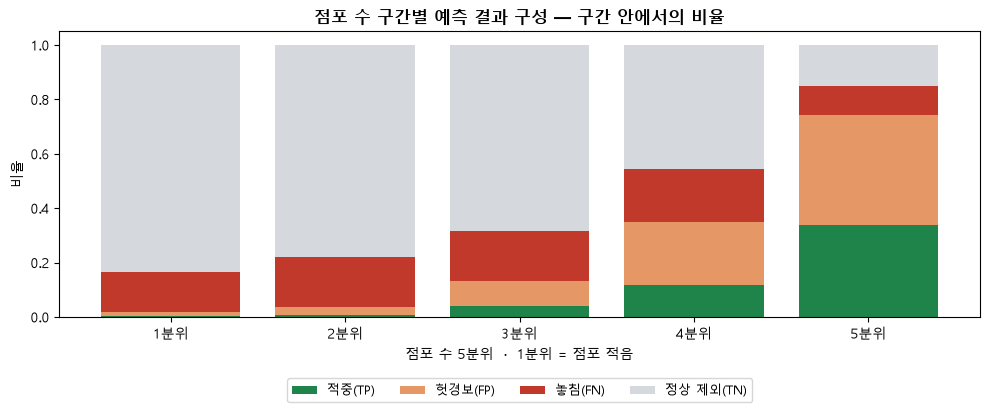

놓침 비율   1분위 14.8% → 5분위 10.7%
헛경보 비율 1분위 1.3% → 5분위 40.3%


In [34]:
ERR_ORDER = ["적중(TP)", "헛경보(FP)", "놓침(FN)", "정상 제외(TN)"]
e1 = pd.crosstab(te["규모구간"], te["결과"], normalize="index").reindex(columns=ERR_ORDER)
e1.index = [f"{int(i)+1}분위" for i in e1.index]
display(e1.round(3))
e2 = pd.crosstab(te["상권유형"], te["결과"], normalize="index").reindex(columns=ERR_ORDER)
display(e2.round(3))

fig, ax = plt.subplots(figsize=(10, 4.4))
COL = {"적중(TP)": "#1e8449", "헛경보(FP)": "#e59866",
       "놓침(FN)": "#c0392b", "정상 제외(TN)": "#d5d8dc"}
bot = np.zeros(len(e1))
for c_ in ERR_ORDER:
    ax.bar(e1.index, e1[c_].values, bottom=bot, color=COL[c_], label=c_)
    bot += e1[c_].values
ax.set_title("점포 수 구간별 예측 결과 구성 — 구간 안에서의 비율", weight="bold", fontsize=12)
ax.set_xlabel("점포 수 5분위  ·  1분위 = 점포 적음"); ax.set_ylabel("비율")
ax.legend(fontsize=9, ncol=4, loc="lower center", bbox_to_anchor=(.5, -.32))
plt.tight_layout(); plt.savefig(FIG / "err_by_size.png", dpi=140); plt.show()

print(f"놓침 비율   1분위 {e1.loc['1분위','놓침(FN)']:.1%} → 5분위 {e1.loc['5분위','놓침(FN)']:.1%}")
print(f"헛경보 비율 1분위 {e1.loc['1분위','헛경보(FP)']:.1%} → 5분위 {e1.loc['5분위','헛경보(FP)']:.1%}")

## 9-3. 놓친 위험(FN)은 어떤 칸인가

**놓친 칸의 성격을 적어 두어야 이 모델을 어디까지 믿을지 정할 수 있음.**

In [35]:
prof = (te.groupby("결과")[["전체_점포_수", "총_유동인구_수", "위험점수"]]
        .median().reindex(ERR_ORDER).round(2))
prof["칸수"] = te["결과"].value_counts().reindex(ERR_ORDER)
display(prof)

fn = te[te["결과"] == "놓침(FN)"]
tp = te[te["결과"] == "적중(TP)"]
print(f"놓친 칸 {len(fn):,}개의 중앙 점포 수 {fn['전체_점포_수'].median():.0f}개 vs "
      f"적중 칸 {tp['전체_점포_수'].median():.0f}개")
print(f"놓친 칸의 위험점수 중앙값 {fn['위험점수'].median():.3f} vs 적중 {tp['위험점수'].median():.3f}")
print(f"놓친 칸 중 «직전 분기에도 순감소»였던 비율 {fn['순감소_현재'].mean():.1%} vs "
      f"적중 {tp['순감소_현재'].mean():.1%}")
print()
print("→ 놓친 칸은 대체로 작고 조용한 칸임. 규모가 작아 사건 자체가 드물어 점수가 낮게 나오는데,")
print("   그 가운데 일부가 실제로 줄어듦. 6-1의 «정체되어 있으나 변화 시 취약» 유형과 같은 자리임.")
print("   → 이 구간은 점수 순위로 좁히는 방식이 아니라 유형(두 축)으로 따로 관리해야 함.")

,전체_점포_수,총_유동인구_수,위험점수,칸수
결과,,,,
적중(TP),36.0,1415929.0,0.65,530
헛경보(FP),28.0,1266077.0,0.61,811
놓침(FN),11.0,933639.0,0.39,893
정상 제외(TN),8.0,845415.0,0.33,3245


놓친 칸 893개의 중앙 점포 수 11개 vs 적중 칸 36개
놓친 칸의 위험점수 중앙값 0.391 vs 적중 0.653
놓친 칸 중 «직전 분기에도 순감소»였던 비율 26.4% vs 적중 30.9%

→ 놓친 칸은 대체로 작고 조용한 칸임. 규모가 작아 사건 자체가 드물어 점수가 낮게 나오는데,
   그 가운데 일부가 실제로 줄어듦. 6-1의 «정체되어 있으나 변화 시 취약» 유형과 같은 자리임.
   → 이 구간은 점수 순위로 좁히는 방식이 아니라 유형(두 축)으로 따로 관리해야 함.


---
# 10. 산출물


In [36]:
te[["기준_년분기_코드", "자치구", "상권_코드", "상권_코드_명", "상권유형",
    "서비스_업종_코드_명", "전체_점포_수", "위험점수", "위험예측", "y"]] \
    .sort_values("위험점수", ascending=False) \
    .to_csv(PROC / "05_risk_scores_2026Q1.csv", index=False, encoding="utf-8-sig")

smap[["자치구", "상권_코드", "상권_코드_명", "상권유형", "서비스_업종_코드_명",
      "전체_점포_수", "경도", "위도", "역거리_m", "위험점수", "위험등급", "y"]]     .sort_values("위험점수", ascending=False)     .to_csv(PROC / "05_risk_by_sangkwon_2026Q1.csv", index=False, encoding="utf-8-sig")

summary = {"선정 모델": BEST, "검증 AP 1위": TOP, "2단계 비교 채택": WIN,
           "검증 AP": round(float(CMP.loc[BEST, "AP"]), 4),
           "테스트 AP": round(float(res["AP"]), 4),
           "테스트 Lift": round(float(res["Lift"]), 4),
           "«점포 수» 기준선 Lift": round(float(size_lift), 4),
           "테스트 기저율": round(float(yte.mean()), 4),
           "피처 수": int(X_all.shape[1]),
           "지도 상권 수": int(len(smap)),
           "경계상자 밖 좌표": int(n_bad)}
json.dump(summary, open(PROC / "05_model_summary.json", "w", encoding="utf-8"),
          ensure_ascii=False, indent=2)

print("[저장] 05_risk_scores_2026Q1.csv       상권 × 업종 위험점수")
print("       05_risk_by_sangkwon_2026Q1.csv  상권 단위 (최고 위험 업종 기준) + 좌표·등급")
print("       05_risk_2026Q1.geojson          QGIS·웹지도용 포인트")
print("       05_model_summary.json")
print("[그림] model_compare · shap_bar · shap_summary · test_result")
print("       gis_bubble · gis_grid_density · gis_rings")
display(pd.Series(summary).to_frame("요약"))

[저장] 05_risk_scores_2026Q1.csv       상권 × 업종 위험점수
       05_risk_by_sangkwon_2026Q1.csv  상권 단위 (최고 위험 업종 기준) + 좌표·등급
       05_risk_2026Q1.geojson          QGIS·웹지도용 포인트
       05_model_summary.json
[그림] model_compare · shap_bar · shap_summary · test_result
       gis_bubble · gis_grid_density · gis_rings


,요약
선정 모델,XGBoost
검증 AP 1위,랜덤포레스트
2단계 비교 채택,2단계 모형
검증 AP,0.398
테스트 AP,0.3994
테스트 Lift,1.5218
«점포 수» 기준선 Lift,1.645
테스트 기저율,0.2597
피처 수,92
지도 상권 수,1357


---
## 정리

- 같은 검증 분기에서 **5종을 비교**함. 다섯 모델의 AP가 좁은 구간에 몰려 있어
  **모델 선택이 결론을 바꾸지 않음.** XGBoost는 1위가 아니지만 `TreeExplainer`로
  정확한 SHAP 분해가 가능해 «무엇이 위험을 만드는가»에 답할 수 있어 채택함.
  1위 모델과는 7-1에서 같은 테스트 분기에 나란히 놓고 보고함.
- 정확도가 아니라 **AP**로 골랐음 — 양성률 26%의 소수 사건에서 «전부 0으로 찍기»만 해도
  정확도가 74.7% 나옴.
- 불균형은 **분할 이후 가중치**로만 다뤘음. 분할 전 오버샘플링이 성능을 부풀리는 경로를 피함.
- **작동점을 검증에서 골라 적용하면 모델 쪽이 분명히 높음**(7-2). 많이 찍는 작동점에서는
  «점포 수» 규칙과 값이 가까워지는데, 많이 찍으면 결국 큰 상권을 다 담게 되어 두 방법이
  같아지기 때문임. 예측 모델 운영은 상위 소수를 찍는 쪽이므로 그 구간의 값이 실무 성능임.
- **규모 구간별로 나눠 보면** 가장 작은 구간에서 «점포 수» 규칙이 1.0(무작위) 아래로 내려감.
  점포가 적은 상권들 사이에서는 «크기»가 아무 정보를 주지 못한다는 뜻이고,
  예측 모델가 실제로 필요한 쪽이 그 구간임.
- **세 표(전체·구간별·작동점별)를 함께 봐야 결론이 성립함.** 하나만 떼면 방향이 반대로 읽힘.
- `y=0`에 섞인 **「변화 없음」** 문제는 `P(사건) × P(순감소 | 사건)` 2단계 모형과 비교해 판정함.
  분해가 정확한 등식임을 값으로 확인했고, **규모 의존이 1단계에 거의 전부 몰린다**는 것도 보였음
  (사건 여부 ~ 점포 수 +0.45 / 순감소|사건 ~ 점포 수 −0.04).
- **후보 변수 4종을 넣어 보고 판정함.** 운영개월 2종은 상권·분기마다 값이 달라 순위에 기여할 수 있고,
  전국 경제지표 2종은 SHAP 순위가 높게 나오더라도 **테스트 분기 안에서 값이 하나뿐**이라
  순위를 바꾸지 못함. 「SHAP이 높다」와 「순위에 기여한다」가 다르다는 것을 보인 기록으로 남김.
- SHAP으로 기여를 분해하고, **규모 계열이 차지하는 몫을 따로 계산**해 EDA 3-1의 우려가
  모델에 얼마나 남아 있는지 수치로 남김.
- 위험도 지도는 «지금 순감소인 곳»이 아니라 **«다음 분기 위험한 곳»** 을 칠했고,
  등급 경계는 보기 좋은 눈금이 아니라 **위험점수 4분위**로 두고 각 등급의 실제 순감소율로 검증함.

### 이 모델이 못 하는 것

- 「폐업」은 실제 폐점이 아니라 **사업자등록 말소** 시점임. 시차가 있음.
- 매출은 단일 카드사 기반 추정치이고, 카드 결제가 잡히지 않는 영세 칸은 결측임.
- 상권 밖의 조건(임대료·상권별 온라인 관심도)은 **상권 코드로 결합할 수 있는 자료가 없어** 넣지 못했음.
  전국 단위 지표는 한 분기 안에서 상수라 순위에 기여하지 못하므로 대체가 되지 않음.
- 테스트가 한 분기이므로, 여기서 나온 성능은 **그 분기의 성능**임. 분기를 늘려 재확인해야 함.
- **단계구분도(주제도)를 그리지 못했음** — 상권 경계 폴리곤이 없음. 좌표 기반 네 레이어로 대체함.
- 동심원 분석의 «역»은 `지하철_역_수 > 0` 인 상권 중심점을 쓴 **대리 위치**임. 실제 역 좌표가 아님.
